# Data processing and integration


## Imports


In [29]:
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import cumulative_trapezoid
from scipy.signal import butter, csd, freqz_sos, sosfiltfilt, welch

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "notebooks" / "pipeline").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Project root could not be located.")
    PROJECT_ROOT = PROJECT_ROOT.parent


COLORS = {"purple": "#5E3C99", "orange": "#D55E00", "green": "#009E73",
          "blue": "#0072B2", "brown": "#8C564B", "yellow": "#E69F00"}
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "lines.linewidth": 1.5,
    "axes.xmargin": 0.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "path.simplify": True,
    "agg.path.chunksize": 10000,
    "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
})


def slug(name):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name)).strip("_").lower()

## Paths


In [30]:
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_FILE = RESULTS_DIR / "loaded_data.pkl"
PREPARED_FILE = RESULTS_DIR / "prepared_signals.pkl"
FIGURES_DIR = PROJECT_ROOT / "figures" / "pipeline" / "2_data_processing_and_integration"
if not DATA_FILE.exists():
    raise FileNotFoundError("results/loaded_data.pkl was not found. Run notebook 1 first.")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Parameters

Band of interest: 50–150 Hz. A 20 Hz high-pass filter removes the integration drift.

In [31]:
G = 9.80665  # m/s^2 per g: converts the signals back to m/s^2
MIN_BAND_HZ = 50.0
MAX_BAND_HZ = 150.0
CUTOFF_HZ = 20.0
FILTER_ORDER = 4
CANDIDATE_CUTOFFS = [0.5, 1.0, 5.0, 10.0, 15.0, 18.0, 20.0, 25.0, 30.0, 40.0]


In [32]:
EXAMPLE_SIGNAL = 0  # signal used for the sanity prints
WELCH_MAX_SEGMENT_SIZE = 8192
WELCH_OVERLAP_FRACTION = 0.75
WELCH_WINDOW = "hann"

## Read and check the data


In [33]:
with DATA_FILE.open("rb") as file:
    data = pickle.load(file)
print("File:", DATA_FILE)
print("Type:", type(data))


File: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\loaded_data.pkl
Type: <class 'dict'>


In [34]:
print("Top-level keys:")
for key, content in data.items():
    if not isinstance(content, dict):
        print(f"  {key:25s} {type(content)}")
        continue
    print(f"  {key:25s} dict with {len(content):3d} items")
    if content:
        first_key = next(iter(content))
        example_value = np.asarray(content[first_key]).squeeze()
        print(
            f"  {'':25s} example: '{first_key}' -> shape {example_value.shape}, dtype {example_value.dtype}"
        )


Top-level keys:
  FRF                       dict with  10 items
                            example: 'FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-down' -> shape (), dtype object
  time_base_split           dict with  10 items
                            example: 'time_base_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up' -> shape (401376,), dtype float64
  time_tip_split            dict with  10 items
                            example: 'time_ponta_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up' -> shape (401376,), dtype float64
  time_axis_split           dict with  20 items
                            example: 'time_base_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up' -> shape (401376,), dtype float64
  relative_acceleration     dict with  10 items
                            example: 'relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_down' -> shape (401377,), dtype float64


In [35]:
def read_signal(name):
    base_key = name.replace("relative_acceleration", "time_base", 1)
    tip_key = name.replace("relative_acceleration", "time_ponta", 1)
    time = np.asarray(data["time_axis_split"][base_key], dtype=float).squeeze()
    base = np.asarray(data["time_base_split"][base_key], dtype=float).squeeze()
    tip = np.asarray(data["time_tip_split"][tip_key], dtype=float).squeeze()
    stored_relative = np.asarray(data["relative_acceleration"][name], dtype=float).squeeze()
    arrays = (time, base, tip, stored_relative)
    if len({len(a) for a in arrays}) != 1 or len(time) < 2:
        raise ValueError(f"Mismatched signal lengths: {name}")
    if not all(np.isfinite(a).all() for a in arrays):
        raise ValueError(f"Nonfinite signal: {name}")
    dt = np.diff(time)
    if np.any(dt <= 0) or not np.allclose(dt, np.median(dt), rtol=1e-6, atol=0):
        raise ValueError(f"Uniform, increasing timestamps required: {name}")
    number_of_points = len(time)
    time = time[:number_of_points]
    base = base[:number_of_points] * G
    tip = tip[:number_of_points] * G
    stored_relative = stored_relative[:number_of_points] * G
    return {
        "name": name,
        "t": time,
        "base_acceleration": base,
        "tip_acceleration": tip,
        "relative_acceleration": tip - base,
        "stored_relative_acceleration": stored_relative,
    }


In [36]:
signal_names = sorted(data["relative_acceleration"])
for name in signal_names:
    base_key = name.replace("relative_acceleration", "time_base", 1)
    tip_key = name.replace("relative_acceleration", "time_ponta", 1)
    assert base_key in data["time_axis_split"], f"Missing time axis: {base_key}"
    assert base_key in data["time_base_split"], f"Missing base signal: {base_key}"
    assert tip_key in data["time_tip_split"], f"Missing tip signal: {tip_key}"
print(f"{len(signal_names)} matching signals checked.")


10 matching signals checked.


In [37]:
example = read_signal(signal_names[EXAMPLE_SIGNAL])
t = example["t"]
base_acceleration = example["base_acceleration"]
relative_acceleration = example["relative_acceleration"]
time_differences = np.diff(t)
dt = float(np.median(time_differences))
fs = 1.0 / dt
nyquist_frequency = fs / 2.0


In [38]:
difference = example["relative_acceleration"] - example["stored_relative_acceleration"]
relative_error = np.sqrt(np.mean(difference**2))
print("Example signal:", example["name"])
print(f"RMS error between stored and recalculated relative acceleration: {relative_error:.3e} m/s²")


Example signal: relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_down
RMS error between stored and recalculated relative acceleration: 3.894e-15 m/s²


In [39]:
print("Approximate unit check:")
acceleration_names = ["base_acceleration", "tip_acceleration", "relative_acceleration"]
for key in acceleration_names:
    signal_rms = np.sqrt(np.mean(example[key] ** 2))
    print(f"  {key:25s} RMS = {signal_rms:10.4f} m/s² = {signal_rms / G:8.4f} g")


Approximate unit check:
  base_acceleration         RMS =     6.9283 m/s² =   0.7065 g
  tip_acceleration          RMS =    38.9160 m/s² =   3.9683 g
  relative_acceleration     RMS =    39.8777 m/s² =   4.0664 g


In [40]:
print("Sampling:")
print("  Number of samples :", len(t))
print("  Duration          : %.2f s" % (t[-1] - t[0]))
print("  Median dt         : %.6e s" % dt)
print("  Minimum dt        : %.6e s" % time_differences.min())
print("  Maximum dt        : %.6e s" % time_differences.max())
print("  dt standard dev.  : %.2e s" % time_differences.std())
print("  Uniform sampling? :", bool(np.allclose(time_differences, dt, rtol=1e-06)))
print("  Sampling frequency: %.2f Hz" % fs)
print("  Nyquist frequency : %.2f Hz" % nyquist_frequency)
print("  Band of interest  : %.0f to %.0f Hz" % (MIN_BAND_HZ, MAX_BAND_HZ))
print("  Samples per cycle at %.0f Hz: %.2f" % (MAX_BAND_HZ, fs / MAX_BAND_HZ))
print("  f_max / Nyquist   : %.2f" % (MAX_BAND_HZ / nyquist_frequency))


Sampling:
  Number of samples : 401377
  Duration          : 1003.44 s
  Median dt         : 2.500000e-03 s
  Minimum dt        : 2.500000e-03 s
  Maximum dt        : 2.500000e-03 s
  dt standard dev.  : 9.65e-14 s
  Uniform sampling? : True
  Sampling frequency: 400.00 Hz
  Nyquist frequency : 200.00 Hz
  Band of interest  : 50 to 150 Hz
  Samples per cycle at 150 Hz: 2.67
  f_max / Nyquist   : 0.75


In [41]:
print("Invalid values:")
values_to_check = ["t", *acceleration_names]
for key in values_to_check:
    values = example[key]
    nan_count = np.isnan(values).sum()
    infinite_count = np.isinf(values).sum()
    print(f"  {key:25s} NaN={nan_count:d} inf={infinite_count:d}")


Invalid values:
  t                         NaN=0 inf=0
  base_acceleration         NaN=0 inf=0
  tip_acceleration          NaN=0 inf=0
  relative_acceleration     NaN=0 inf=0


In [42]:
print("Signal means:")
print("  relative acceleration = %.6e m/s²" % relative_acceleration.mean())
print("  base acceleration     = %.6e m/s²" % base_acceleration.mean())


Signal means:
  relative acceleration = 3.763851e-05 m/s²
  base acceleration     = -6.729744e-05 m/s²


## Butterworth high-pass filter


In [43]:
def design_high_pass(cutoff_hz, sampling_frequency, order=FILTER_ORDER):
    return butter(
        N=order,
        Wn=cutoff_hz,
        btype="highpass",
        analog=False,
        output="sos",
        fs=sampling_frequency,
    )


In [44]:
def high_pass(signal, cutoff_hz, sampling_frequency, order=FILTER_ORDER):
    sos = design_high_pass(cutoff_hz, sampling_frequency, order)
    return sosfiltfilt(sos=sos, x=signal, axis=-1, padtype="odd", padlen=None)


In [45]:
test_frequencies = np.array([0.5, 1.0, 5.0, 20.0, 50.0, 100.0, 150.0])
filter_rows = []
for cutoff in CANDIDATE_CUTOFFS:
    sos = design_high_pass(cutoff, fs)
    _, response = freqz_sos(sos=sos, worN=test_frequencies, whole=False, fs=fs)
    zero_phase_gain = np.abs(response) ** 2
    row = {"cutoff_Hz": cutoff}
    for frequency_value, gain in zip(test_frequencies, zero_phase_gain):
        column = f"|H| {frequency_value:.0f}Hz"
        row[column] = gain
    filter_rows.append(row)


In [46]:
filter_table = pd.DataFrame(filter_rows)
filter_table = filter_table.set_index("cutoff_Hz")
print("Zero-phase filter gain")
display(filter_table.style.format("{:.4f}"))


Zero-phase filter gain


,|H| 0Hz,|H| 1Hz,|H| 5Hz,|H| 20Hz,|H| 50Hz,|H| 100Hz,|H| 150Hz
cutoff_Hz,,,,,,,
0.500000,0.5000,0.9961,1.0000,1.0000,1.0000,1.0000,1.0000
1.000000,0.0039,0.5000,1.0000,1.0000,1.0000,1.0000,1.0000
5.000000,0.0000,0.0000,0.5000,1.0000,1.0000,1.0000,1.0000
10.000000,0.0000,0.0000,0.0038,0.9963,1.0000,1.0000,1.0000
15.000000,0.0000,0.0000,0.0001,0.9114,1.0000,1.0000,1.0000
18.000000,0.0000,0.0000,0.0000,0.7017,0.9998,1.0000,1.0000
20.000000,0.0000,0.0000,0.0000,0.5000,0.9995,1.0000,1.0000
25.000000,0.0000,0.0000,0.0000,0.1391,0.9972,1.0000,1.0000
30.000000,0.0000,0.0000,0.0000,0.0346,0.9874,1.0000,1.0000


In [47]:
selected_sos = design_high_pass(CUTOFF_HZ, fs)
filter_frequency, filter_response = freqz_sos(sos=selected_sos, worN=4096, whole=False, fs=fs)
filter_zero_phase_gain = np.abs(filter_response) ** 2


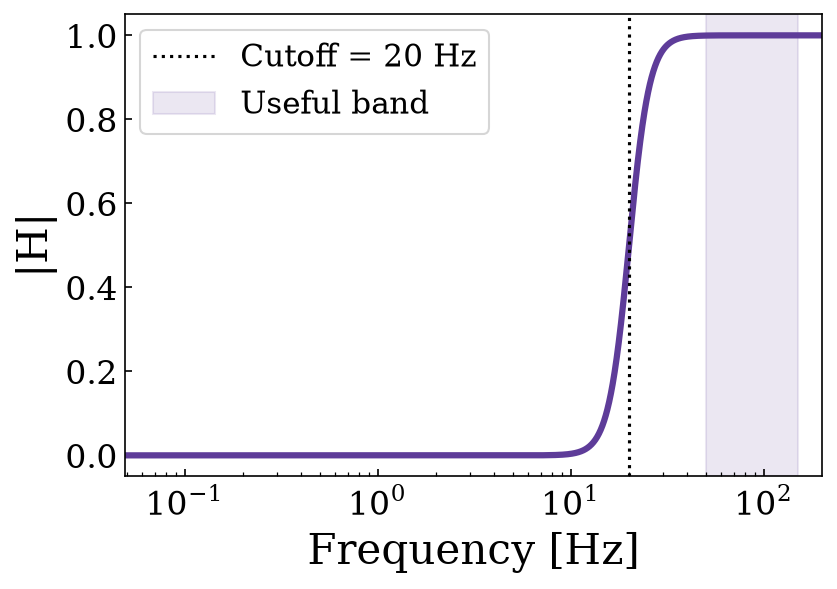

In [88]:
plt.figure()
plt.semilogx(filter_frequency[1:], filter_zero_phase_gain[1:], linewidth=3, alpha=1)
plt.axvline(CUTOFF_HZ, color="k", ls=":", label=f"Cutoff = {CUTOFF_HZ:.0f} Hz")
plt.axvspan(
    MIN_BAND_HZ, MAX_BAND_HZ, color=COLORS["purple"], alpha=0.12, label="Useful band"
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H|")
plt.legend()
plt.savefig(FIGURES_DIR / "high_pass_butterworth_frequency_response.pdf")
plt.show()


## Integrate the signals

Trapezoidal and spectral integration (division by $i\omega$) are compared; spectral integration is used afterwards because the trapezoidal rule attenuates the upper band at $f_s = 400$ Hz.

In [49]:
def integrate_fft(signal, sampling_frequency):
    frequencies = np.fft.rfftfreq(len(signal), d=1.0 / sampling_frequency)
    spectrum = np.fft.rfft(signal, n=len(signal), axis=-1, norm="backward")
    angular_frequencies = 2.0 * np.pi * frequencies
    integrated_spectrum = np.zeros_like(spectrum)
    positive = frequencies > 0
    integrated_spectrum[positive] = spectrum[positive] / (1j * angular_frequencies[positive])
    return np.fft.irfft(integrated_spectrum, n=len(signal), axis=-1, norm="backward")


In [50]:
def integrate_trapezoidal(acceleration, time, sampling_frequency):
    velocity_raw = cumulative_trapezoid(y=acceleration, x=time, axis=-1, initial=0.0)
    displacement_raw = cumulative_trapezoid(y=velocity_raw, x=time, axis=-1, initial=0.0)
    velocity = high_pass(velocity_raw, CUTOFF_HZ, sampling_frequency)
    displacement = cumulative_trapezoid(y=velocity, x=time, axis=-1, initial=0.0)
    displacement = high_pass(displacement, CUTOFF_HZ, sampling_frequency)
    return (velocity_raw, displacement_raw, velocity, displacement)


In [51]:
def integrate_spectral(acceleration, sampling_frequency):
    velocity_raw = integrate_fft(acceleration, sampling_frequency)
    displacement_raw = integrate_fft(velocity_raw, sampling_frequency)
    velocity = high_pass(velocity_raw, CUTOFF_HZ, sampling_frequency)
    displacement = integrate_fft(velocity, sampling_frequency)
    displacement = high_pass(displacement, CUTOFF_HZ, sampling_frequency)
    return (velocity_raw, displacement_raw, velocity, displacement)


In [52]:
integration_examples = {}
for name in signal_names:
    signal = read_signal(name)
    signal_fs = 1.0 / np.median(np.diff(signal["t"]))
    trapezoidal = integrate_trapezoidal(signal["relative_acceleration"], signal["t"], signal_fs)
    spectral = integrate_spectral(signal["relative_acceleration"], signal_fs)
    integration_examples[name] = {
        "t": signal["t"], "fs": signal_fs, "acceleration": signal["relative_acceleration"],
        "trapezoidal": trapezoidal, "spectral": spectral,
    }
vA_raw, xA_raw, vA, xA = integration_examples[signal_names[EXAMPLE_SIGNAL]]["trapezoidal"]
vB_raw, xB_raw, vB, xB = integration_examples[signal_names[EXAMPLE_SIGNAL]]["spectral"]

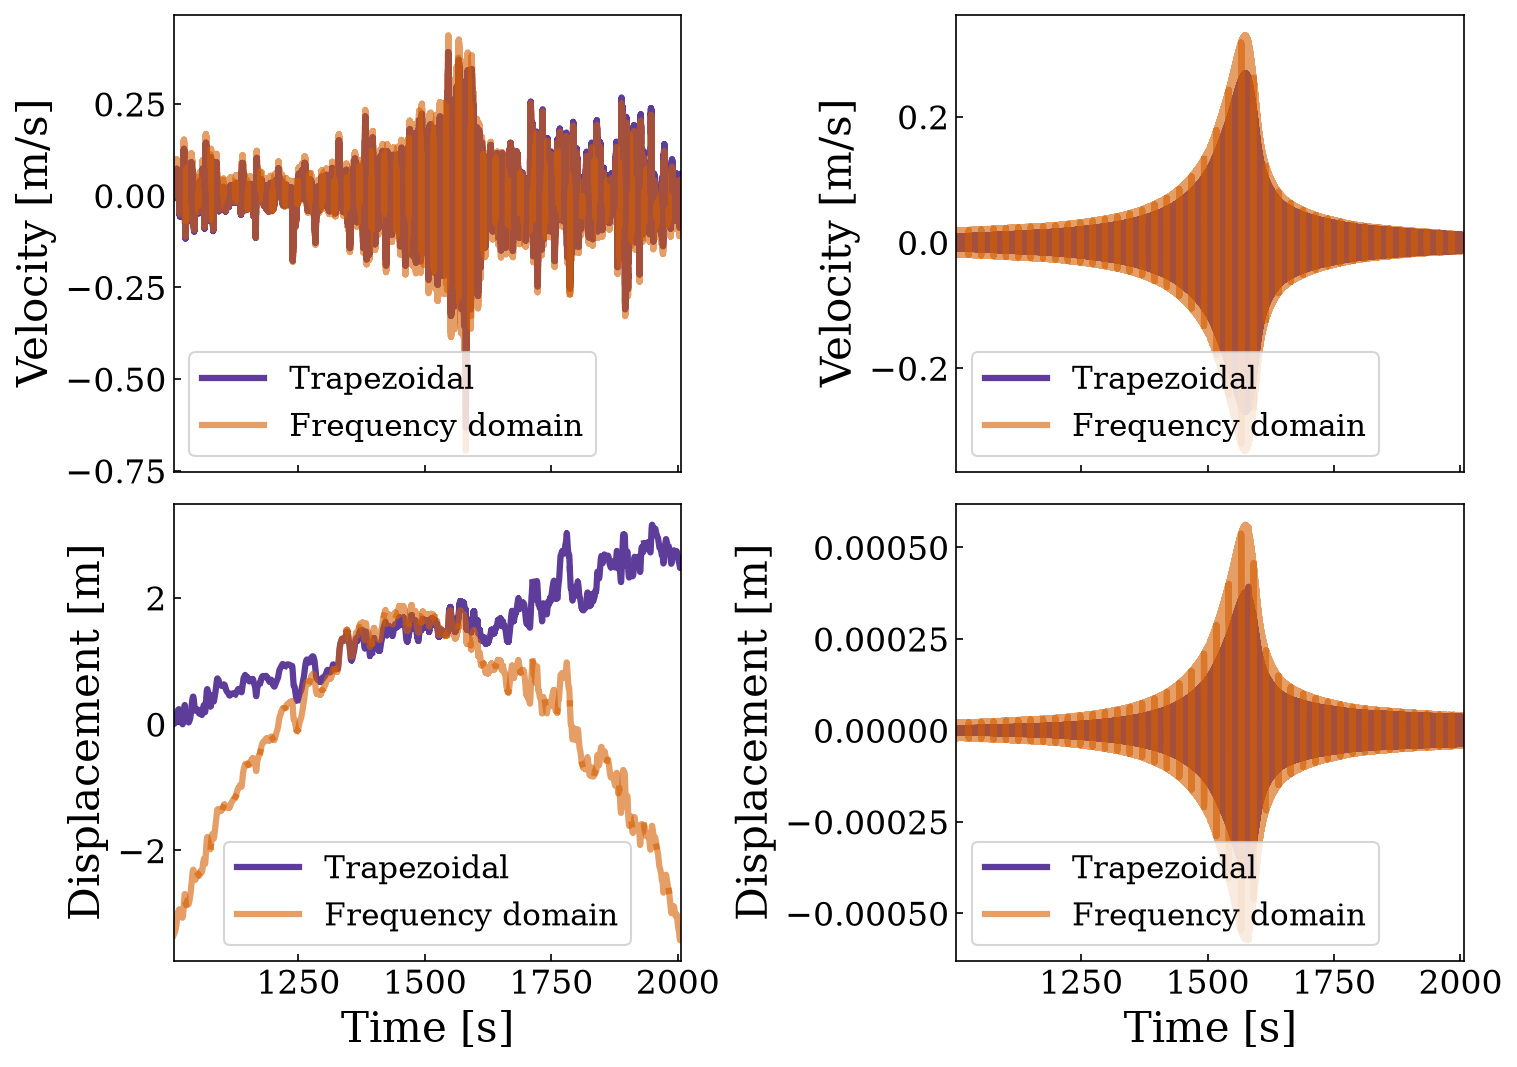

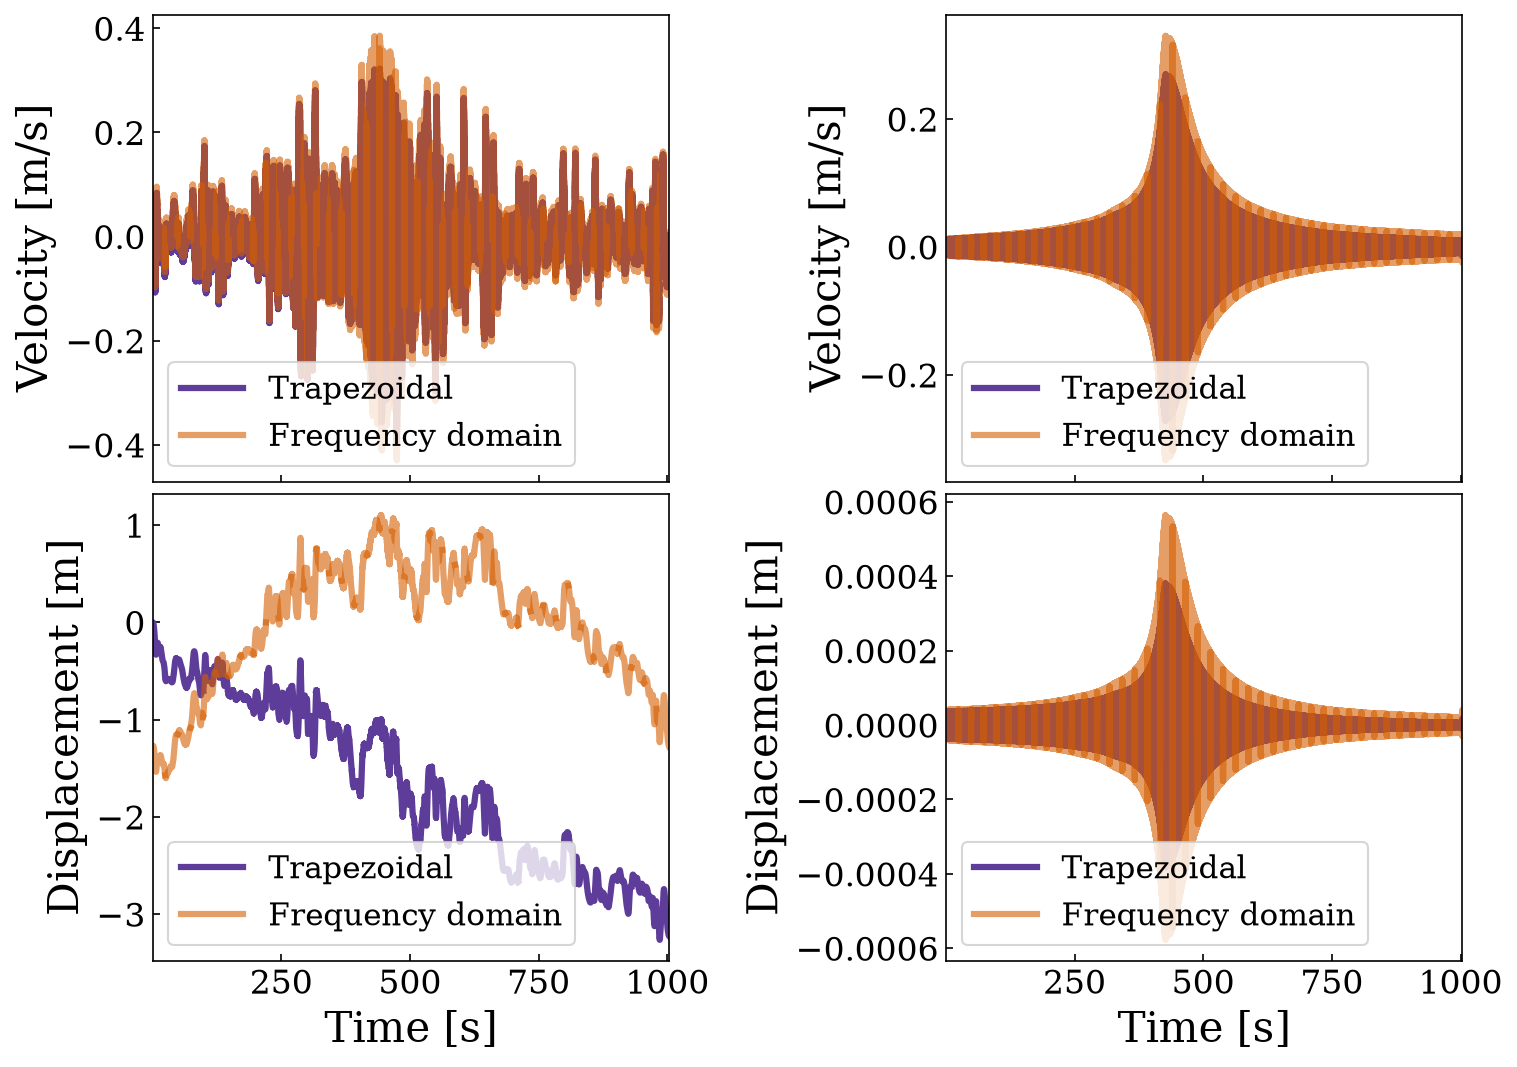

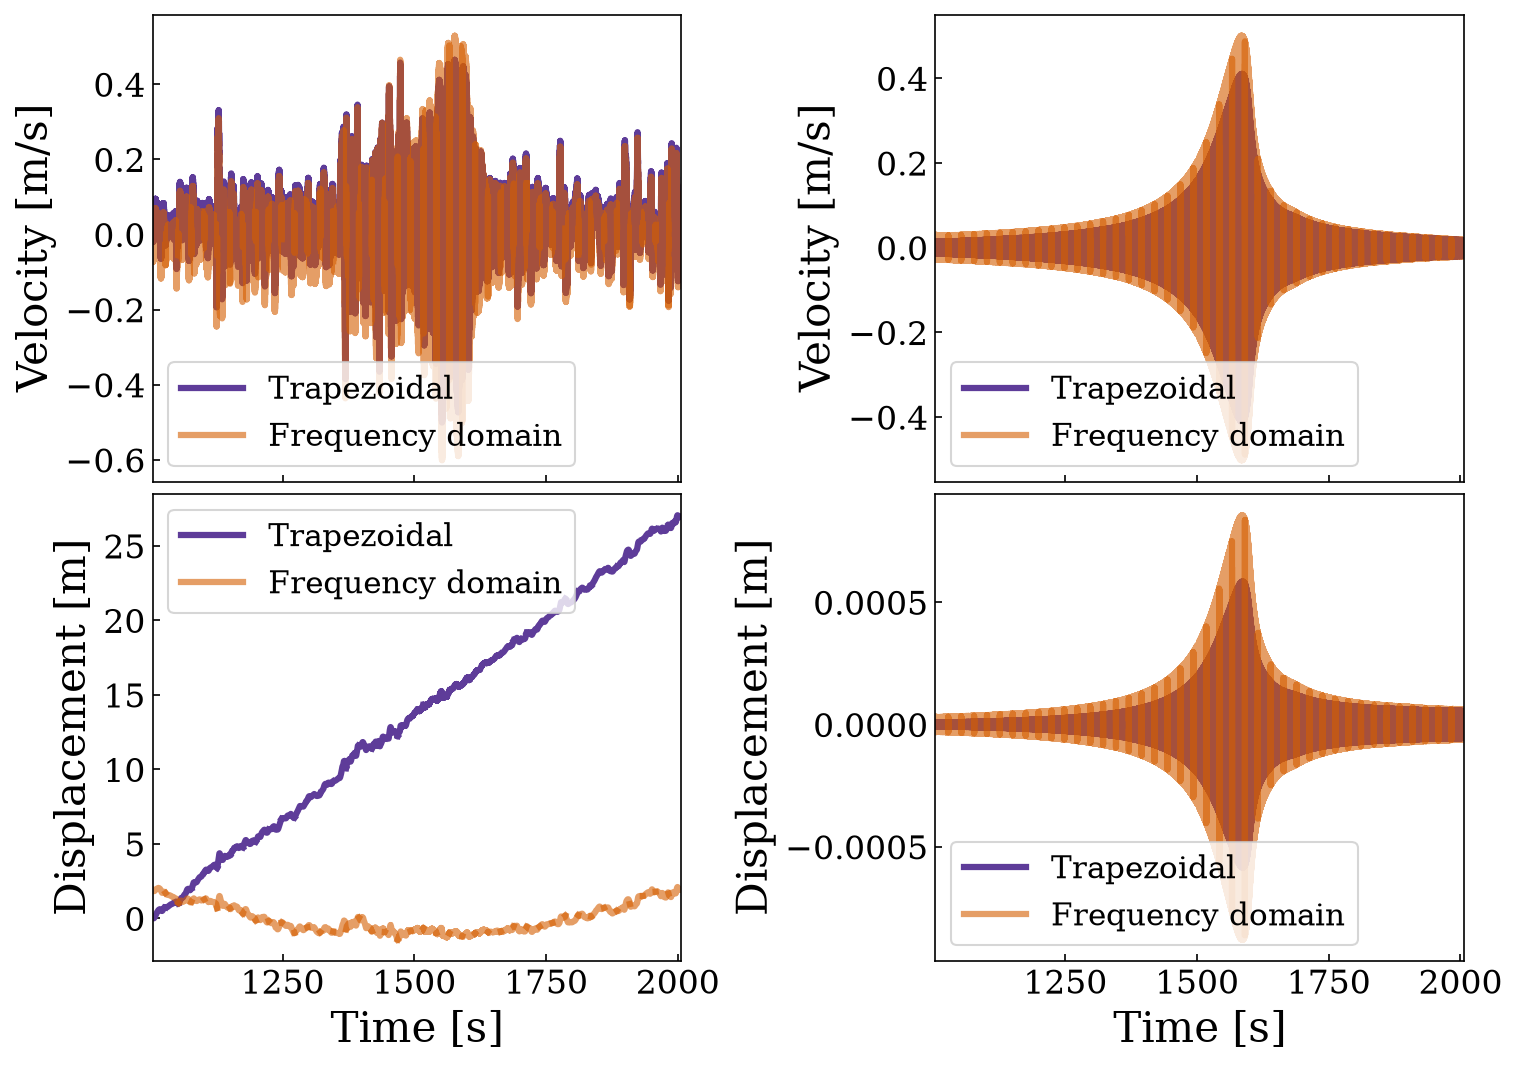

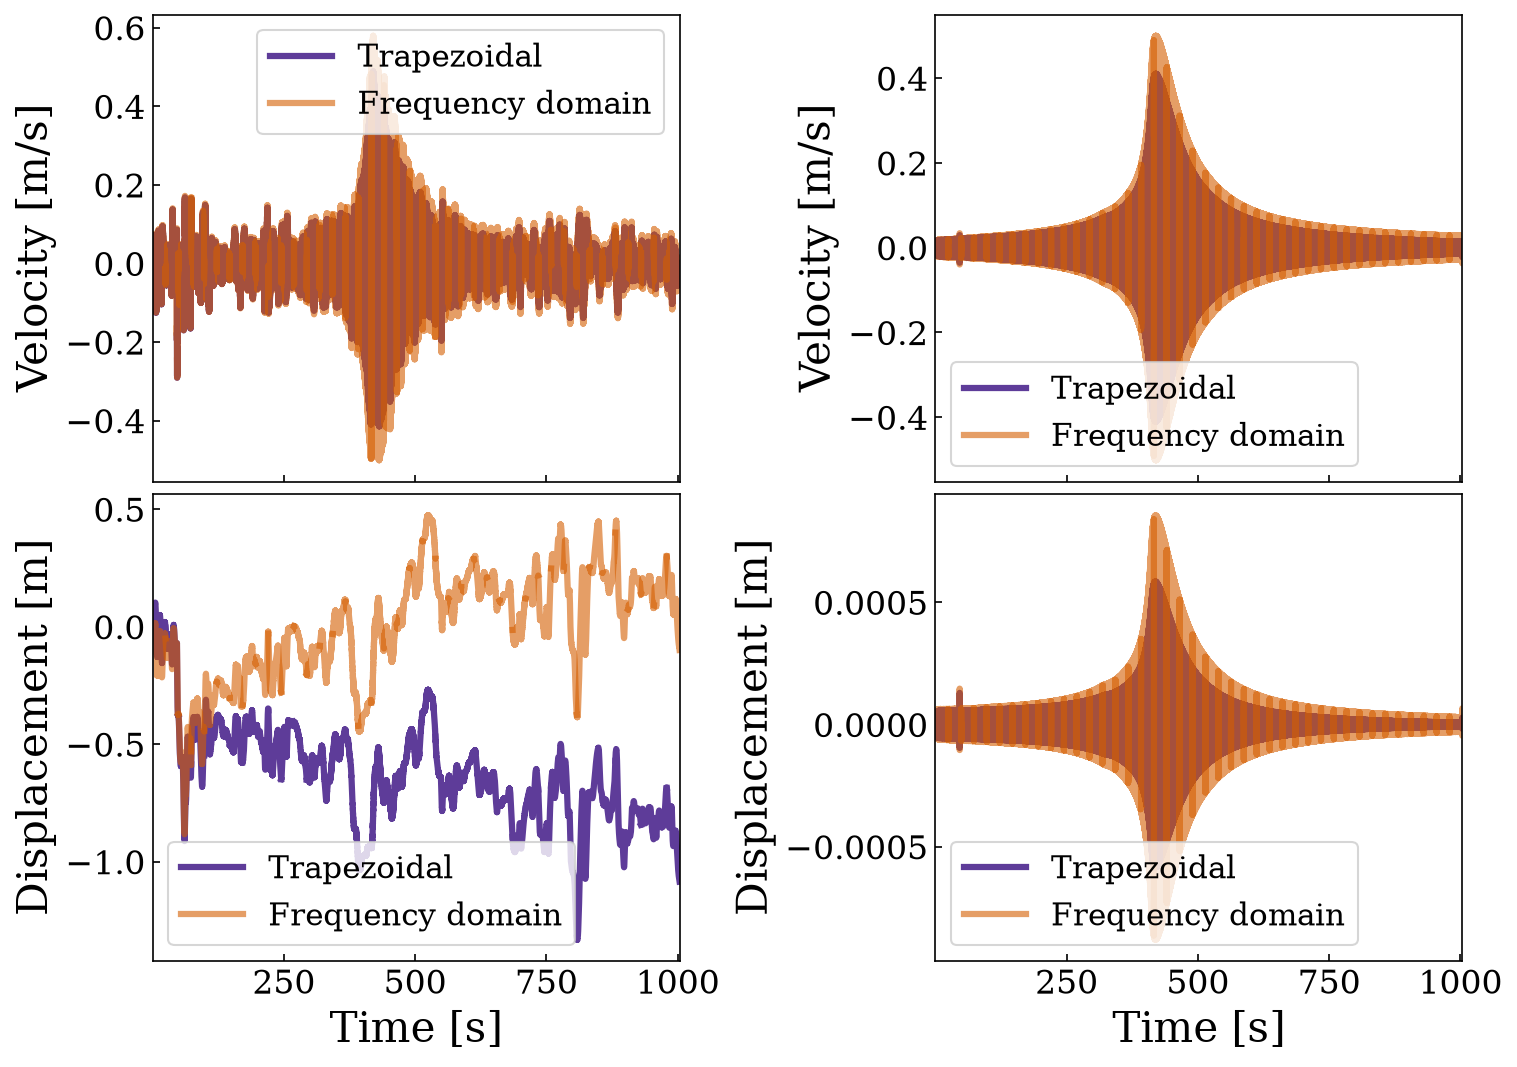

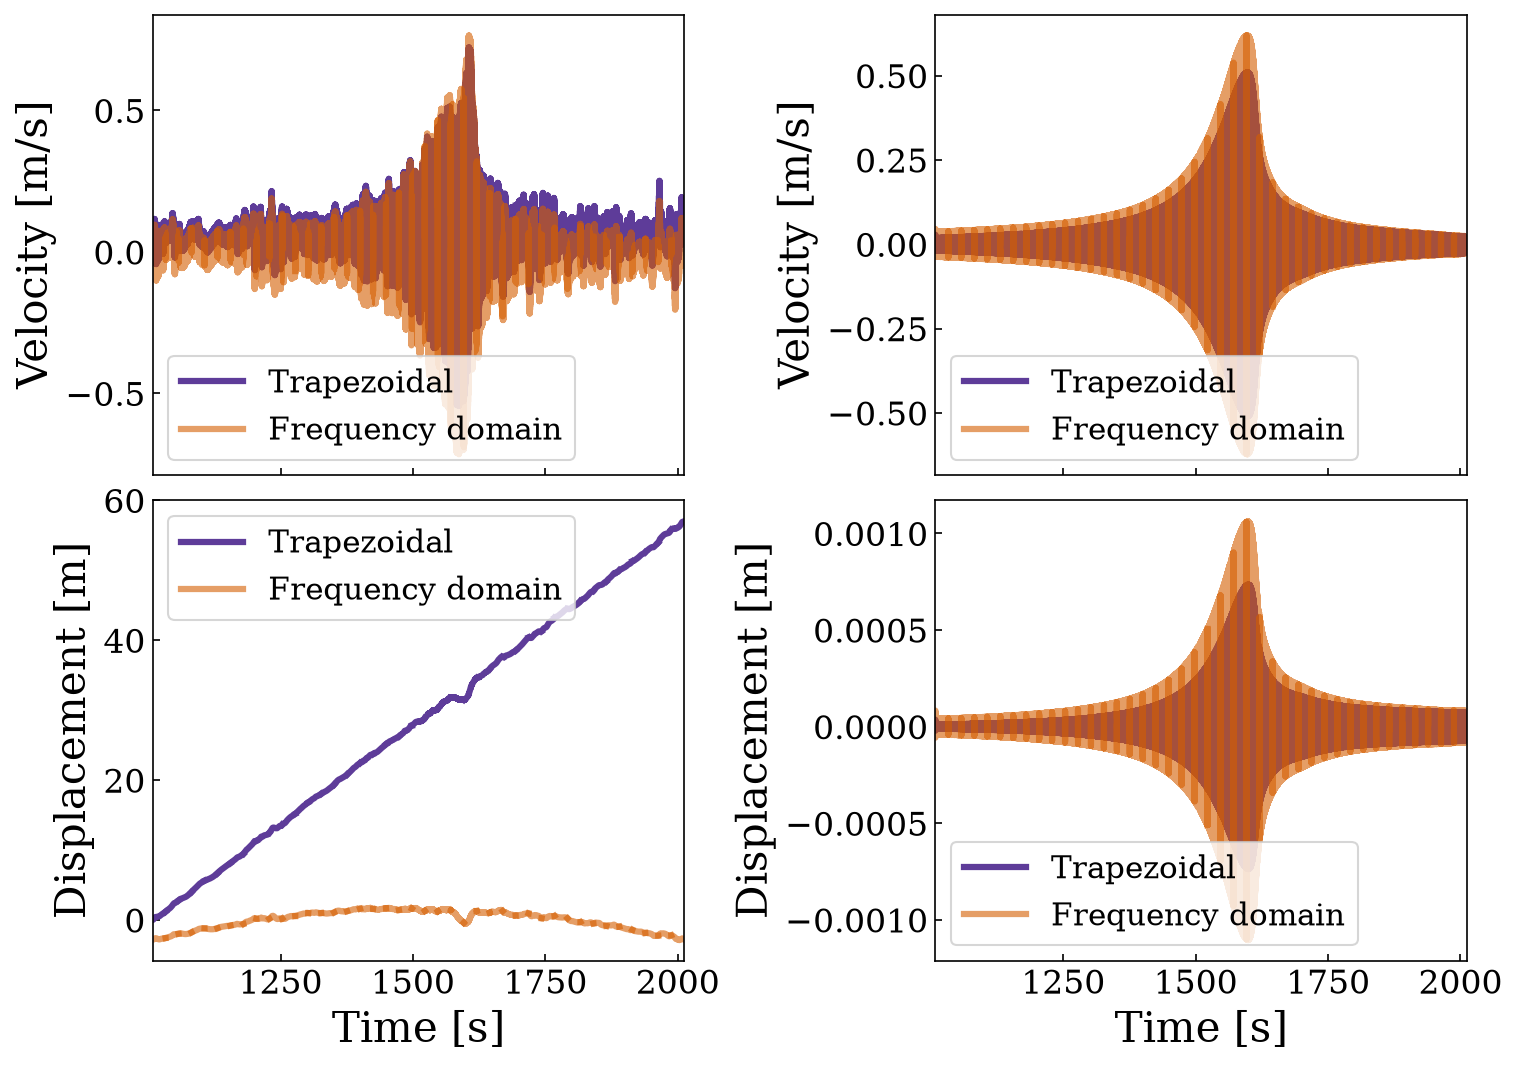

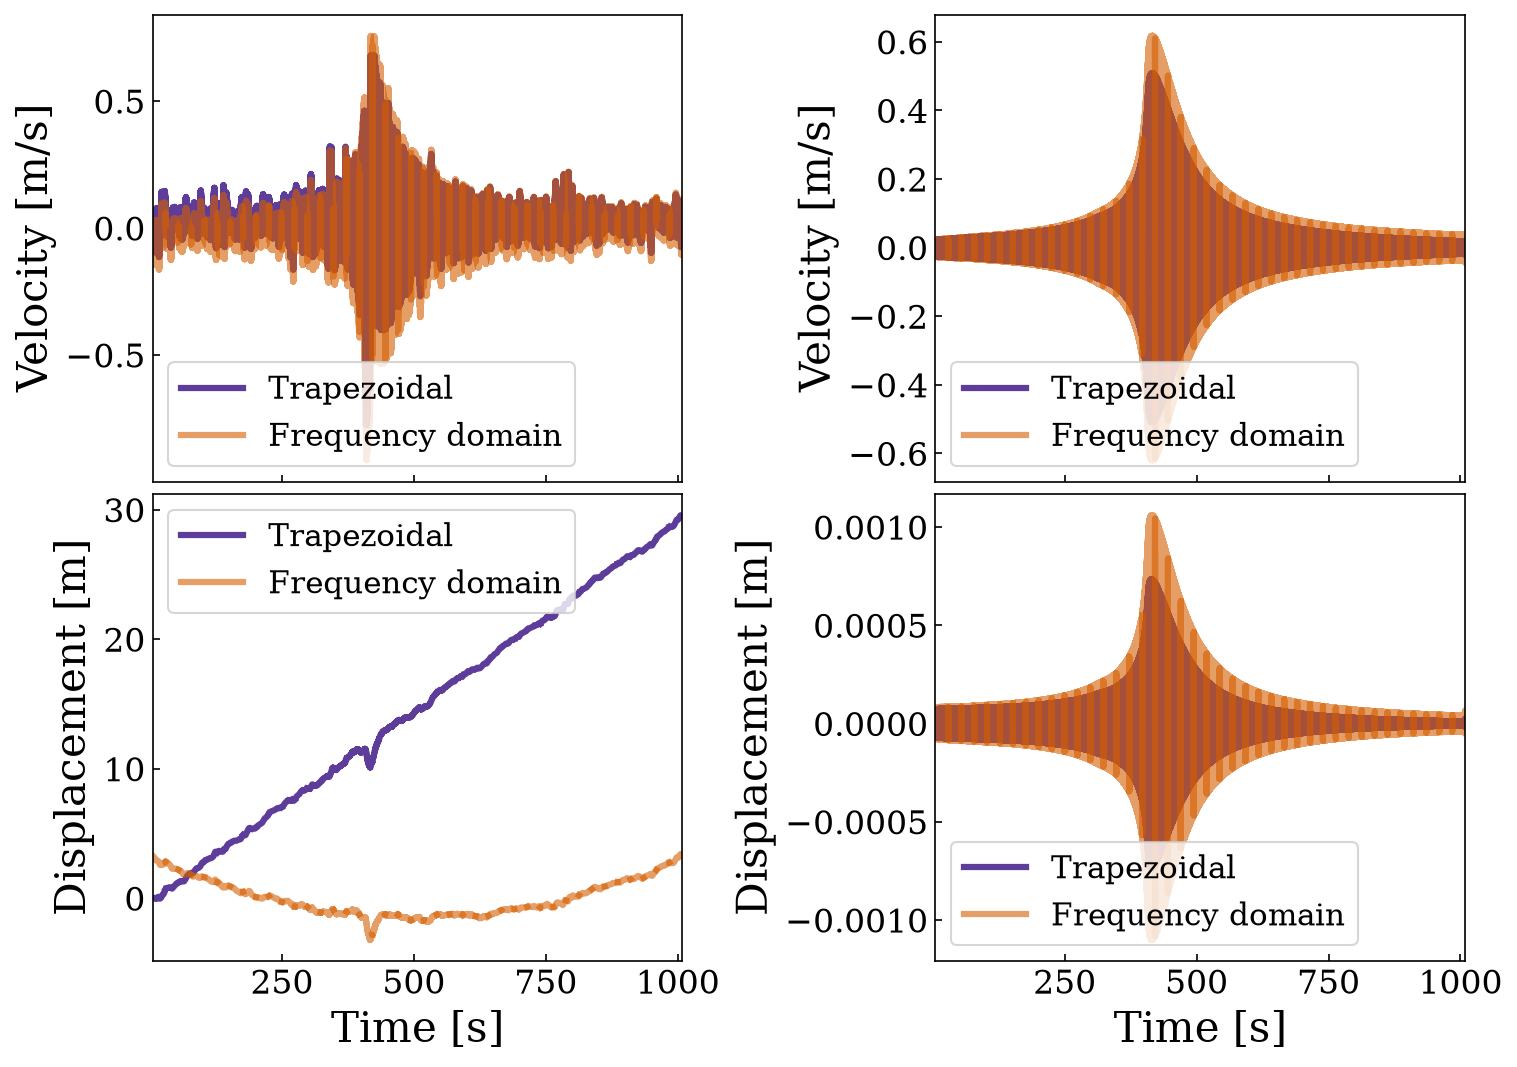

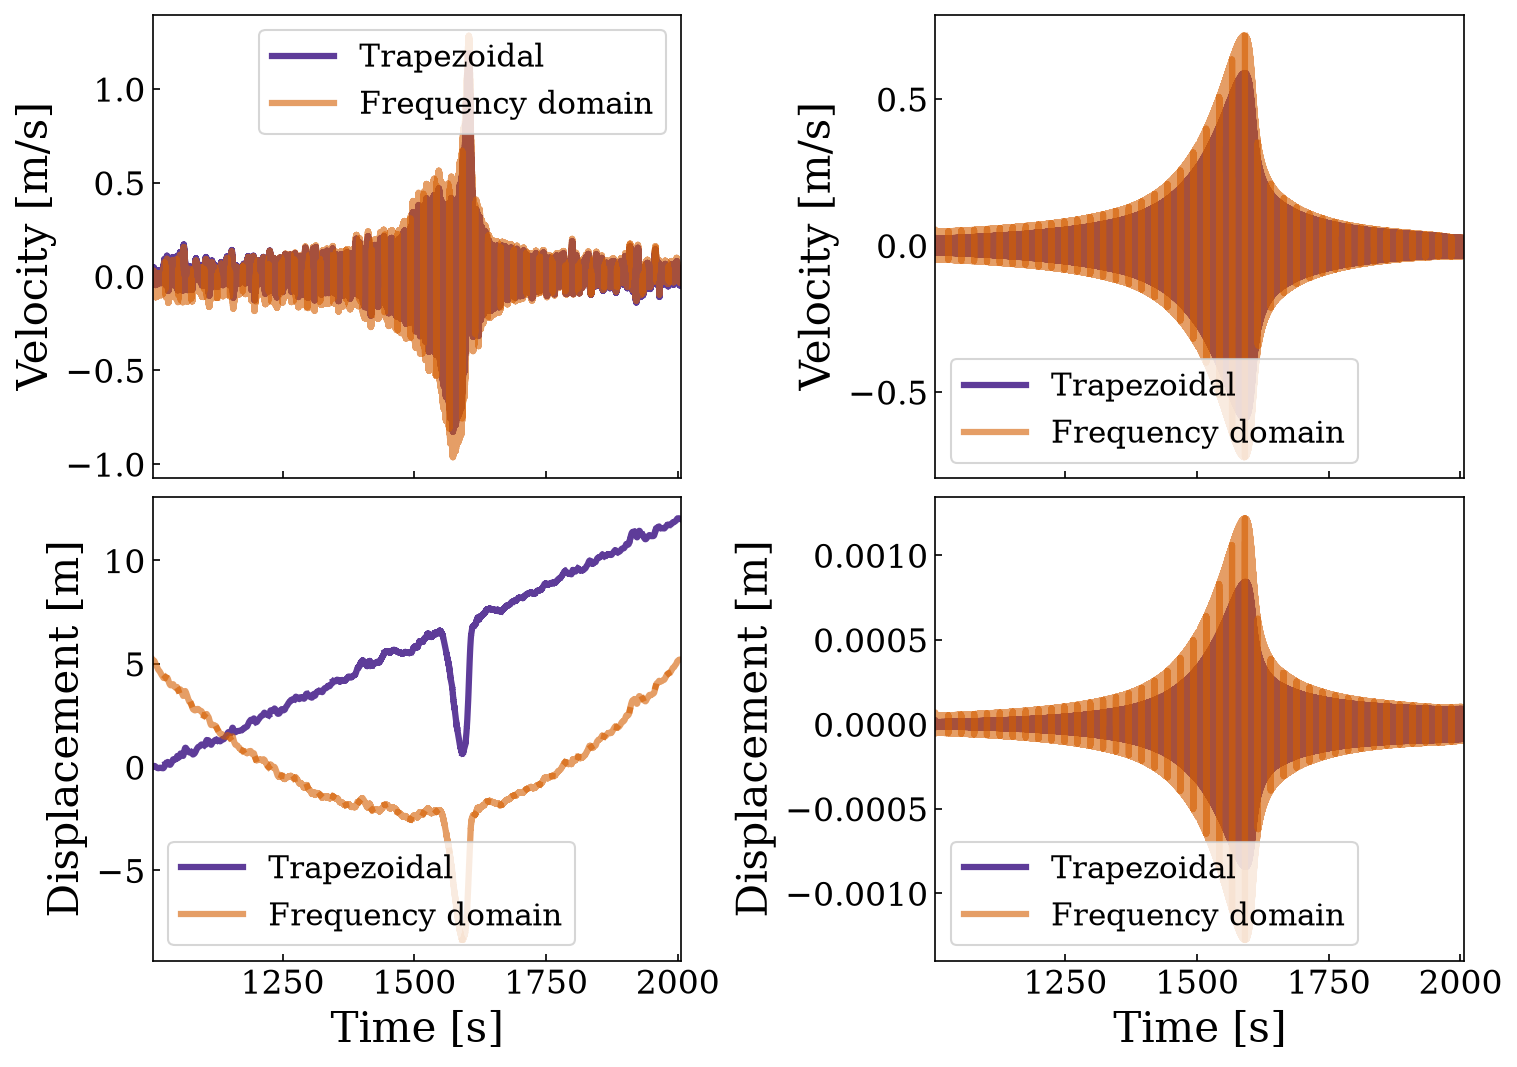

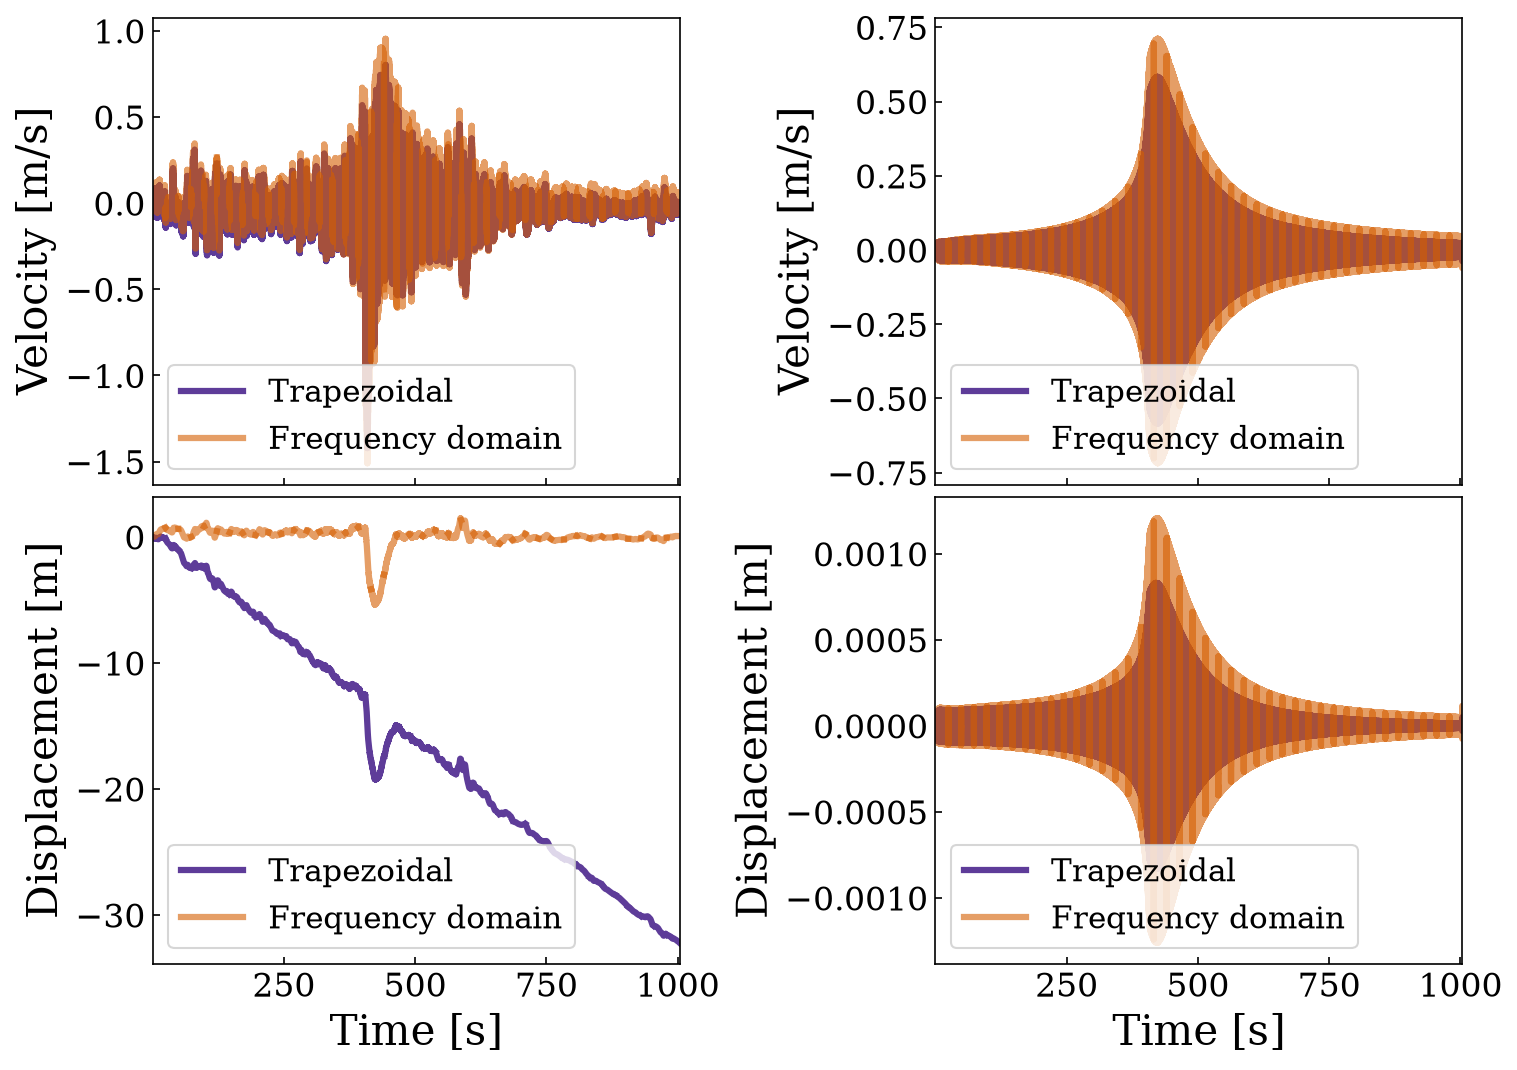

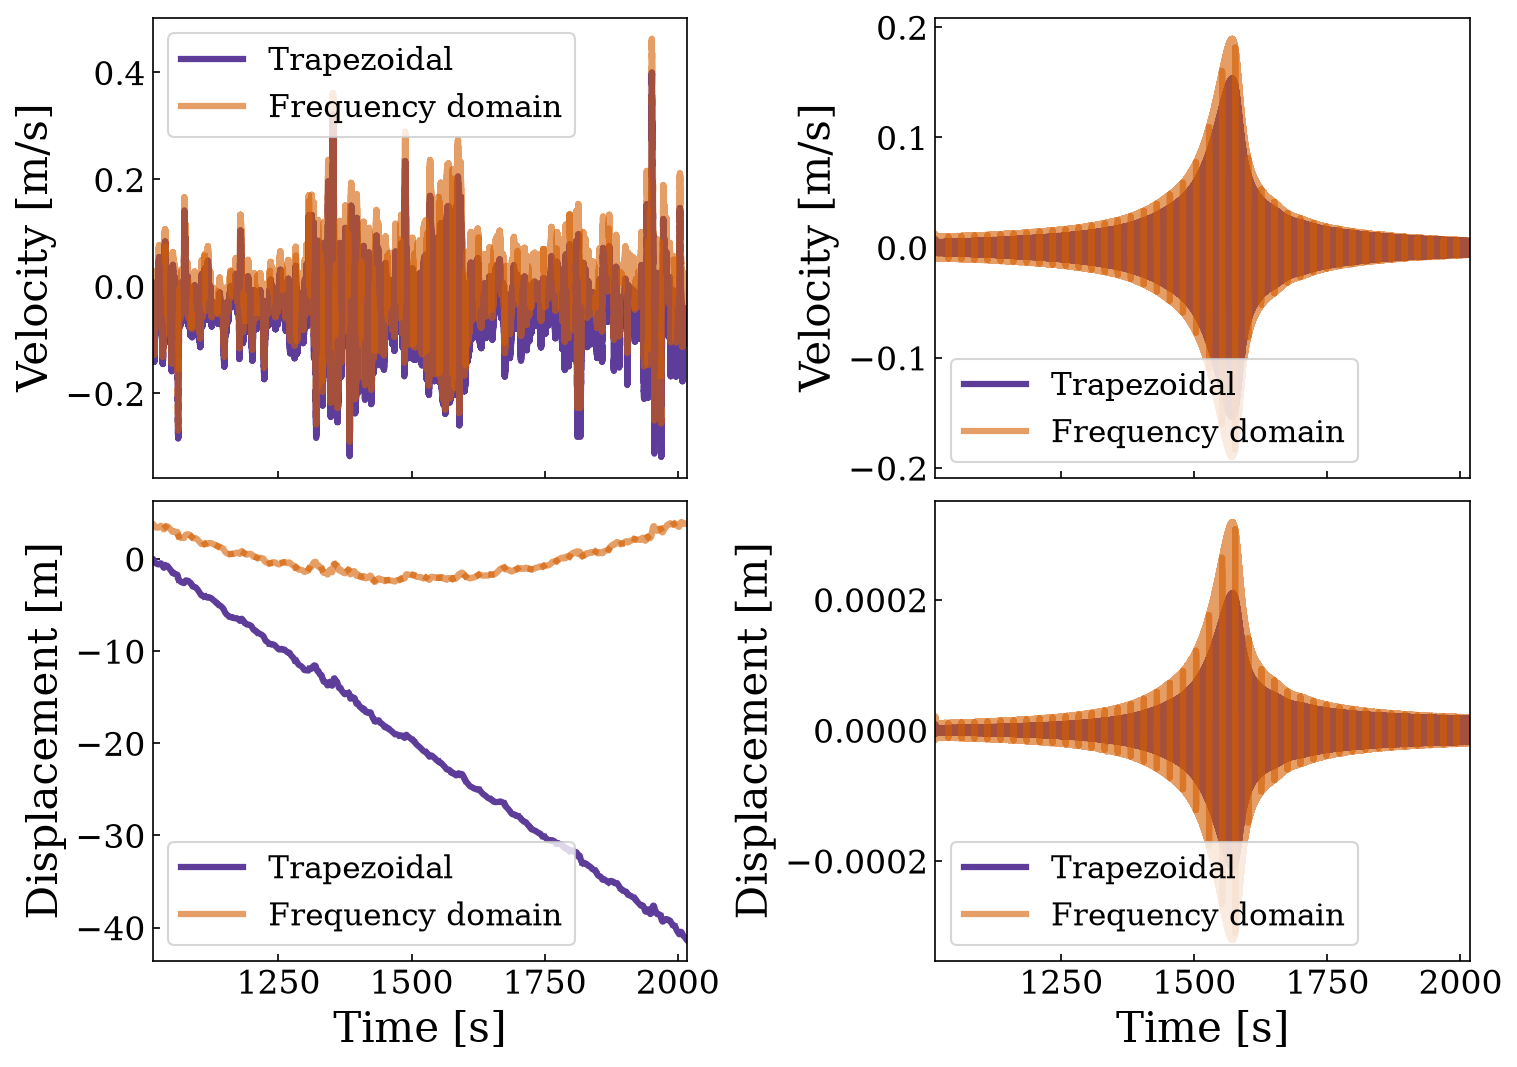

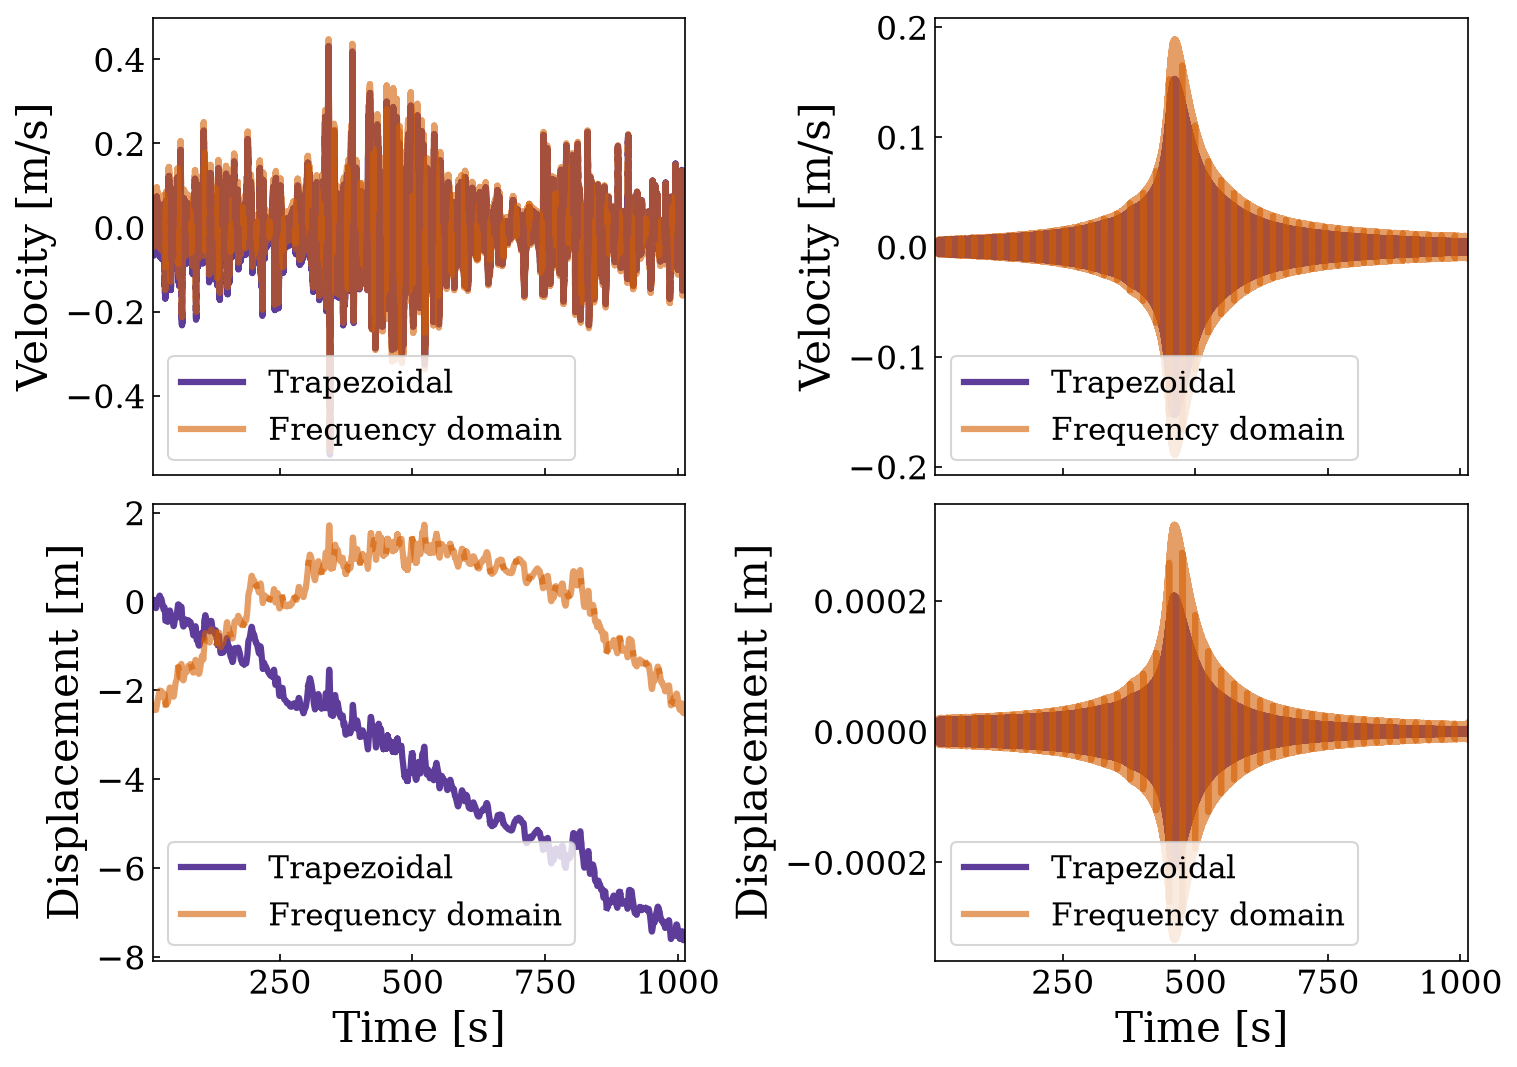

In [84]:
for name, item in integration_examples.items():
    t_s = item["t"]
    (vA_raw_s, xA_raw_s, vA_s, xA_s), (vB_raw_s, xB_raw_s, vB_s, xB_s) = item["trapezoidal"], item["spectral"]
    figure, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, layout="constrained")
    for ax, (a_values, b_values, ylabel) in zip(
        axes.ravel(),
        [(vA_raw_s, vB_raw_s, "Velocity [m/s]"), (vA_s, vB_s, "Velocity [m/s]"),
         (xA_raw_s, xB_raw_s, "Displacement [m]"), (xA_s, xB_s, "Displacement [m]")],
    ):
        ax.plot(t_s, a_values, lw=3, alpha=1, label="Trapezoidal")
        ax.plot(t_s, b_values, lw=3, alpha=0.6, label="Frequency domain")
        ax.set_ylabel(ylabel)
        ax.legend()
    axes[1, 0].set_xlabel("Time [s]")
    axes[1, 1].set_xlabel("Time [s]")
    figure.savefig(FIGURES_DIR / f"integration_comparison_{slug(name)}.pdf")
    plt.show()
    plt.close(figure)

### Integration gain


In [54]:
def spectral_ratio(estimated, acceleration, sampling_frequency, integration_order):
    number_of_samples = len(acceleration)
    sample_spacing = 1.0 / sampling_frequency
    frequencies = np.fft.rfftfreq(number_of_samples, d=sample_spacing)
    acceleration_spectrum = np.fft.rfft(acceleration, norm="backward")
    estimated_spectrum = np.fft.rfft(estimated, norm="backward")
    angular_frequencies = 2.0 * np.pi * frequencies
    ideal_spectrum = np.zeros_like(acceleration_spectrum)
    positive_frequency = frequencies > 0
    ideal_spectrum[positive_frequency] = (
        acceleration_spectrum[positive_frequency]
        / (1j * angular_frequencies[positive_frequency]) ** integration_order
    )
    estimated_magnitude = np.abs(estimated_spectrum)
    ideal_magnitude = np.abs(ideal_spectrum)
    return (frequencies, estimated_magnitude, ideal_magnitude)


def trapezoidal_gain(frequency, sampling_frequency):
    argument = np.pi * frequency / sampling_frequency
    return argument / np.tan(argument)


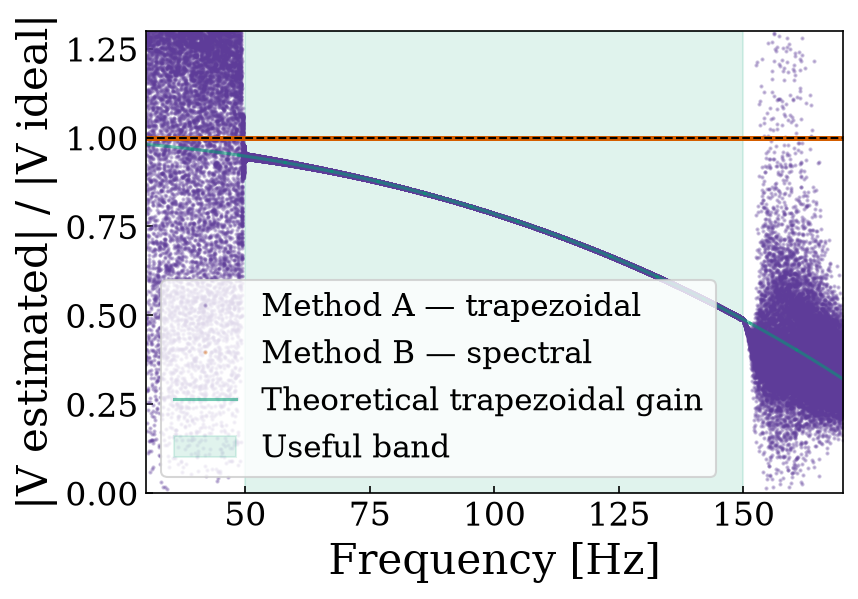

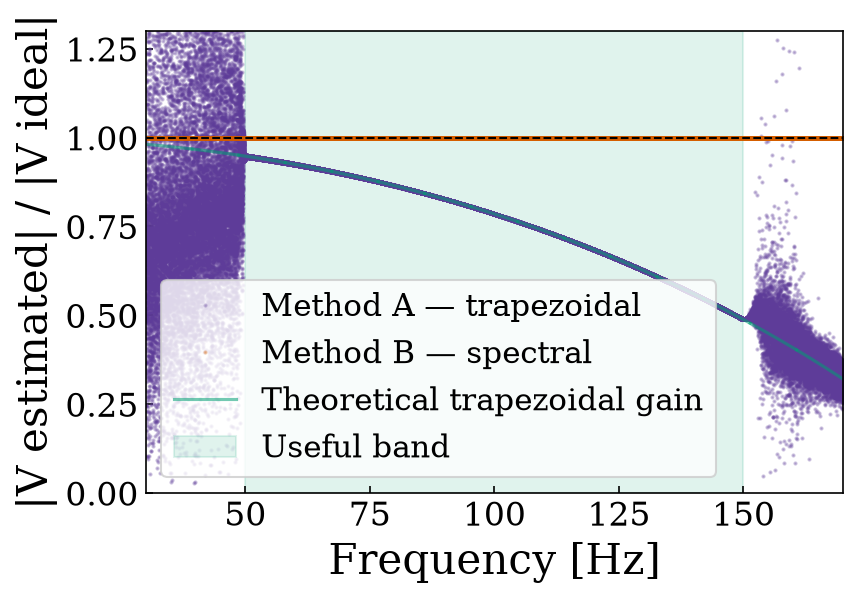

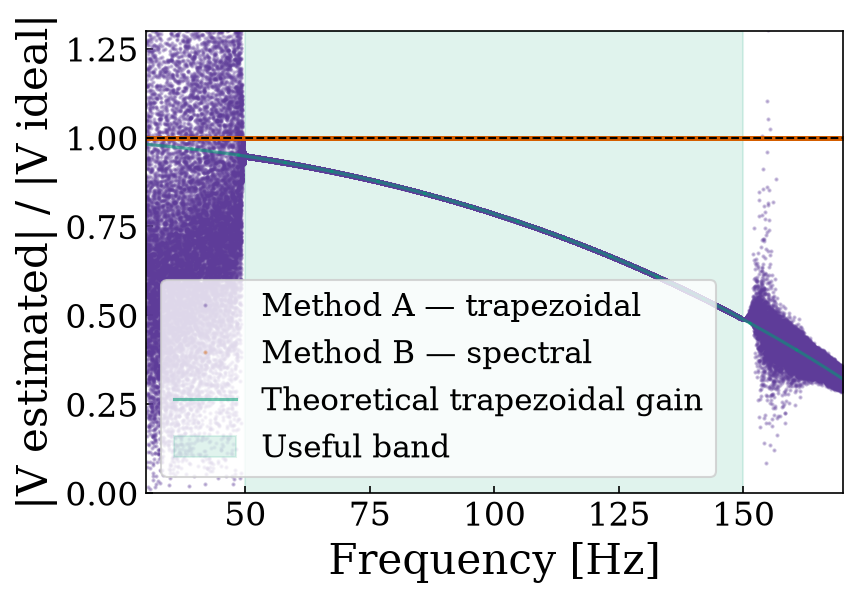

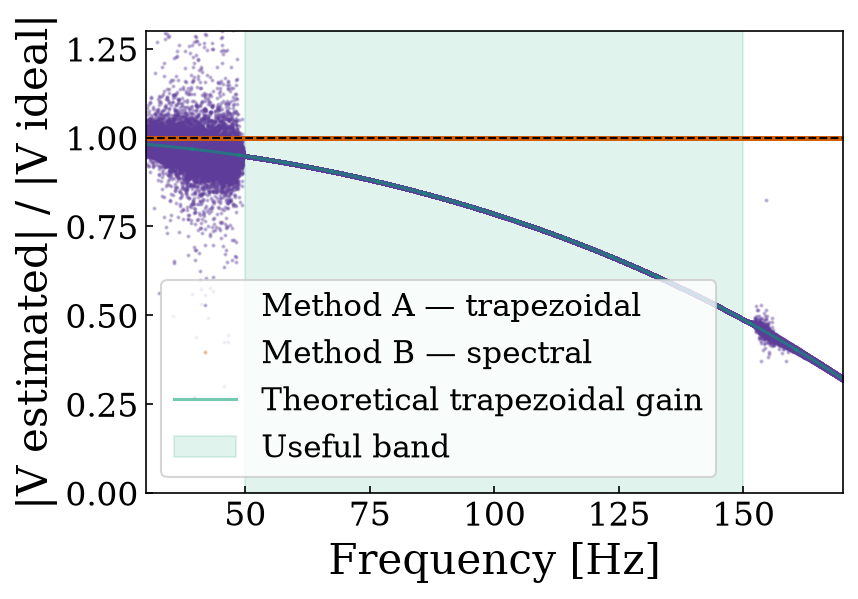

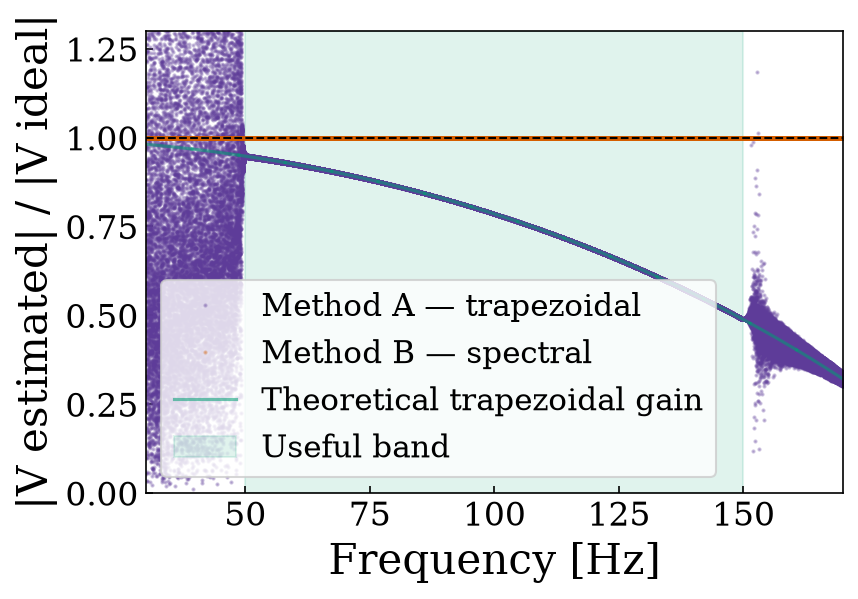

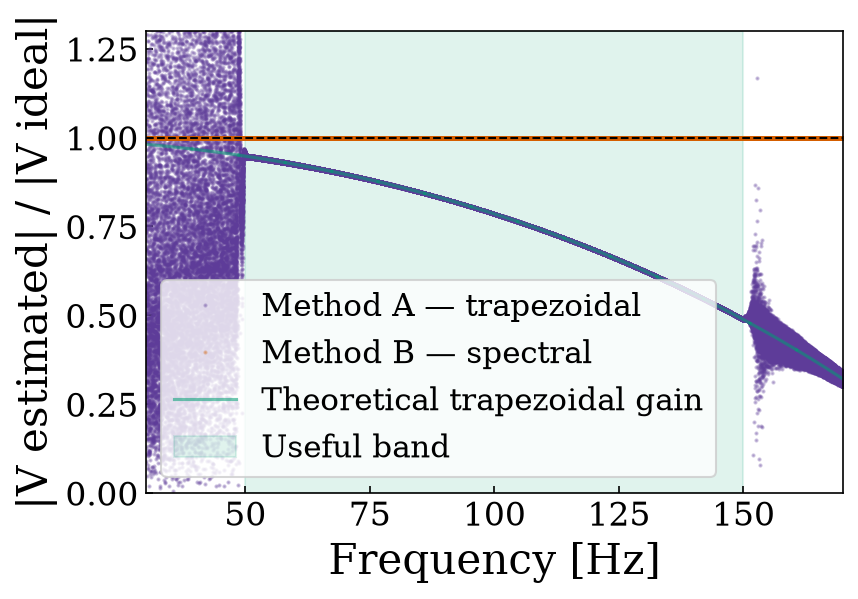

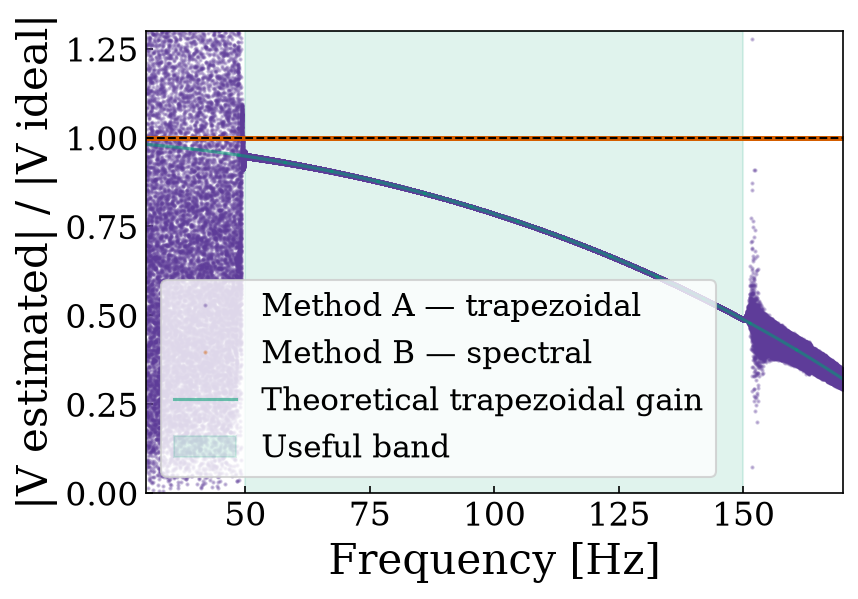

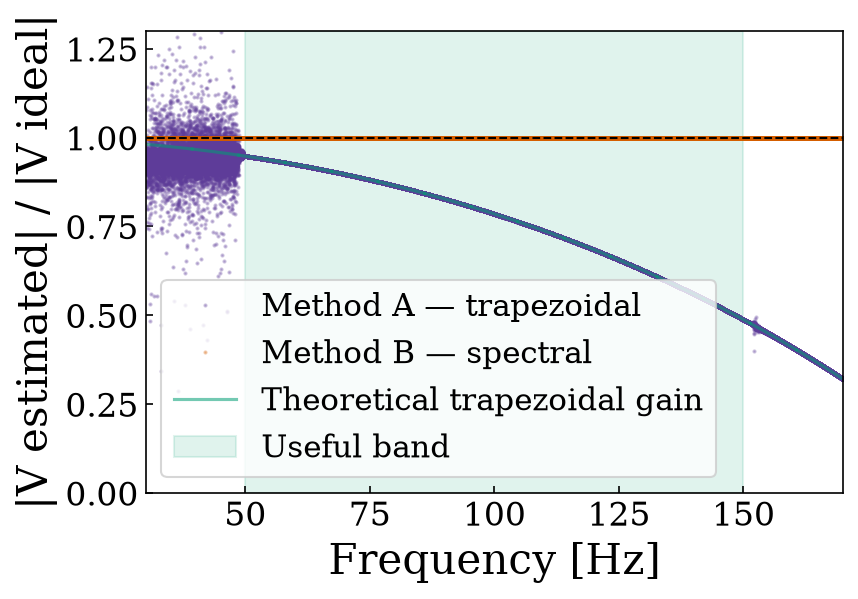

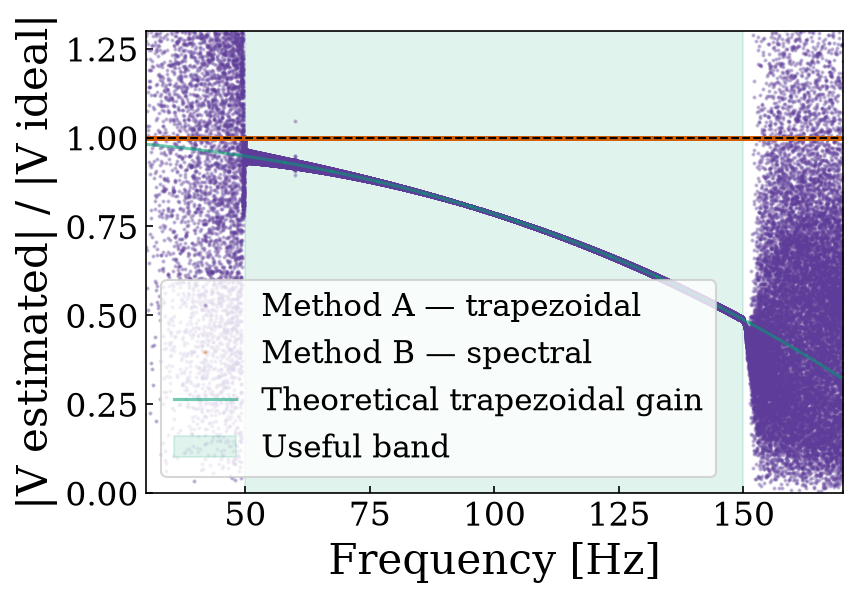

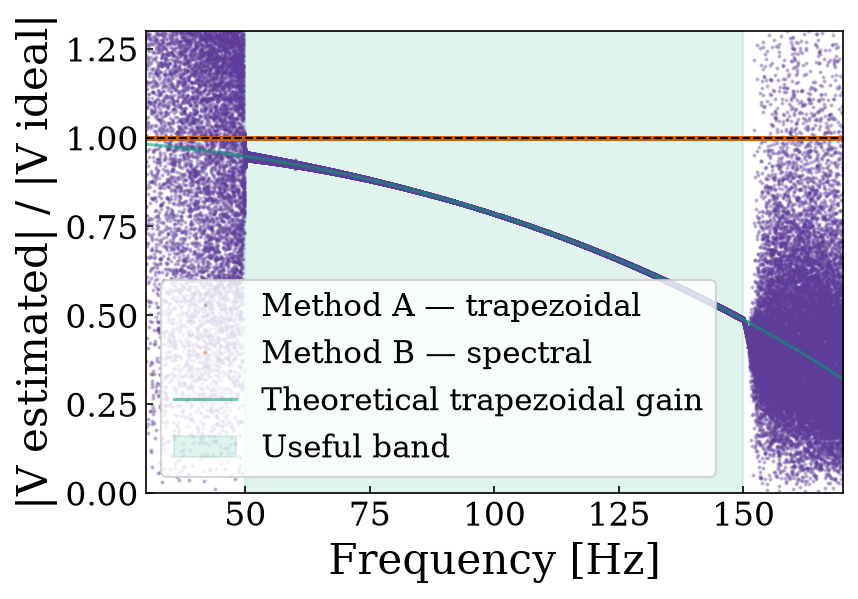

In [55]:
for name, item in integration_examples.items():
    vA_raw_s, vB_raw_s = item["trapezoidal"][0], item["spectral"][0]
    frequencies, magnitude_vA, ideal_magnitude = spectral_ratio(vA_raw_s, item["acceleration"], item["fs"], 1)
    _, magnitude_vB, _ = spectral_ratio(vB_raw_s, item["acceleration"], item["fs"], 1)
    comparison_band = (frequencies >= 30) & (frequencies <= 170) & (ideal_magnitude > 0)
    plt.figure()
    plt.plot(frequencies[comparison_band], magnitude_vA[comparison_band] / ideal_magnitude[comparison_band],
             ".", ms=2, alpha=0.3, label="Method A — trapezoidal")
    plt.plot(frequencies[comparison_band], magnitude_vB[comparison_band] / ideal_magnitude[comparison_band],
             ".", ms=2, alpha=0.3, label="Method B — spectral")
    plt.plot(frequencies[comparison_band], trapezoidal_gain(frequencies[comparison_band], item["fs"]),
             lw=1.5, alpha=0.55, label="Theoretical trapezoidal gain")
    plt.axhline(1.0, color="k", ls="--", lw=1)
    plt.axvspan(MIN_BAND_HZ, MAX_BAND_HZ, color=COLORS["green"], alpha=0.12, label="Useful band")
    plt.ylim(0, 1.3)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("|V estimated| / |V ideal|")
    plt.legend()
    plt.savefig(FIGURES_DIR / f"integration_coherence_sweep_band_{slug(name)}.pdf")
    plt.show()
    plt.close()

In [56]:
print("Theoretical amplitude preserved by trapezoidal integration:")
for frequency_value in [MIN_BAND_HZ, 100.0, MAX_BAND_HZ]:
    gain = trapezoidal_gain(frequency_value, fs)
    print(f"  {frequency_value:6.1f} Hz: {gain:.4f}")


Theoretical amplitude preserved by trapezoidal integration:
    50.0 Hz: 0.9481
   100.0 Hz: 0.7854
   150.0 Hz: 0.4880


## Measured and calculated FRFs


In [57]:
def calculate_frf(input_signal, output_signal, sampling_frequency):
    segment_size = min(WELCH_MAX_SEGMENT_SIZE, len(input_signal))
    overlap = int(WELCH_OVERLAP_FRACTION * segment_size)
    frequencies, input_spectrum = welch(
        x=input_signal,
        fs=sampling_frequency,
        window=WELCH_WINDOW,
        nperseg=segment_size,
        noverlap=overlap,
        nfft=None,
        detrend="constant",
        return_onesided=True,
        scaling="density",
        axis=-1,
        average="mean",
    )
    _, cross_spectrum = csd(
        x=input_signal,
        y=output_signal,
        fs=sampling_frequency,
        window=WELCH_WINDOW,
        nperseg=segment_size,
        noverlap=overlap,
        nfft=None,
        detrend="constant",
        return_onesided=True,
        scaling="density",
        axis=-1,
        average="mean",
    )
    transfer_function = np.zeros_like(cross_spectrum, dtype=complex)
    valid_input = input_spectrum > np.finfo(float).eps
    transfer_function[valid_input] = cross_spectrum[valid_input] / input_spectrum[valid_input]
    return (frequencies, np.abs(transfer_function))


### Measured versus calculated FRFs


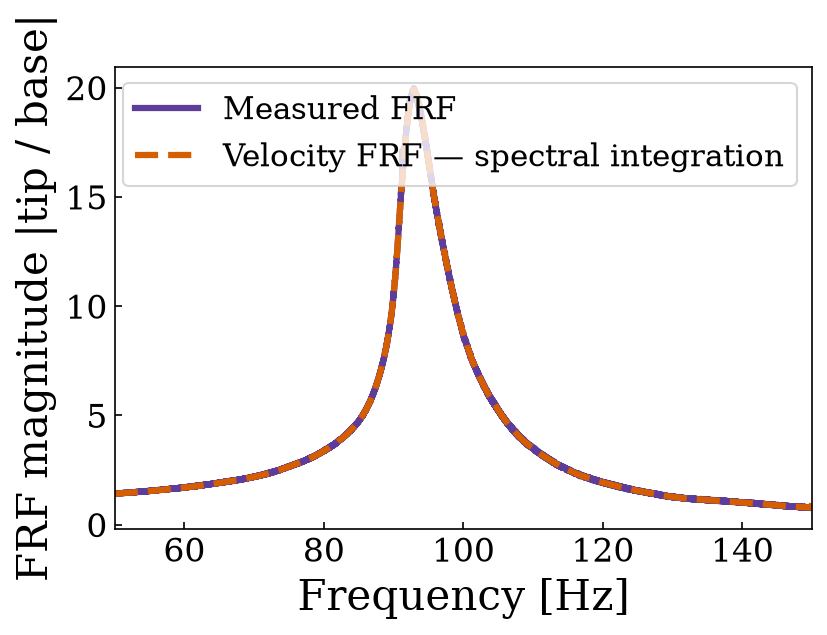

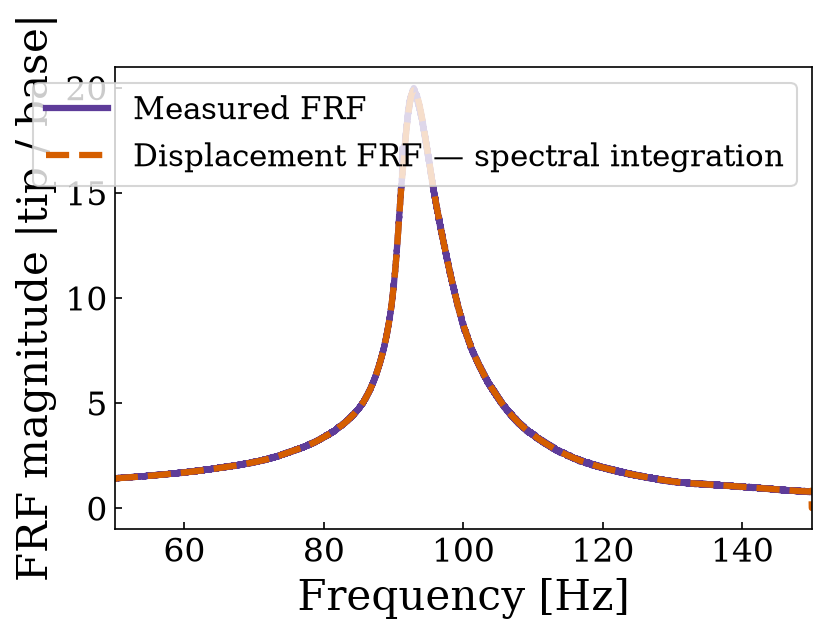

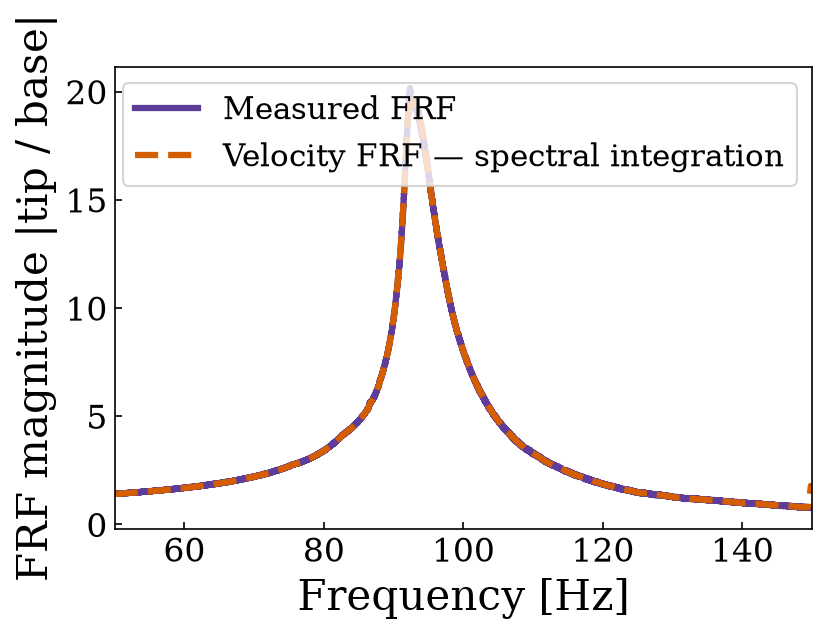

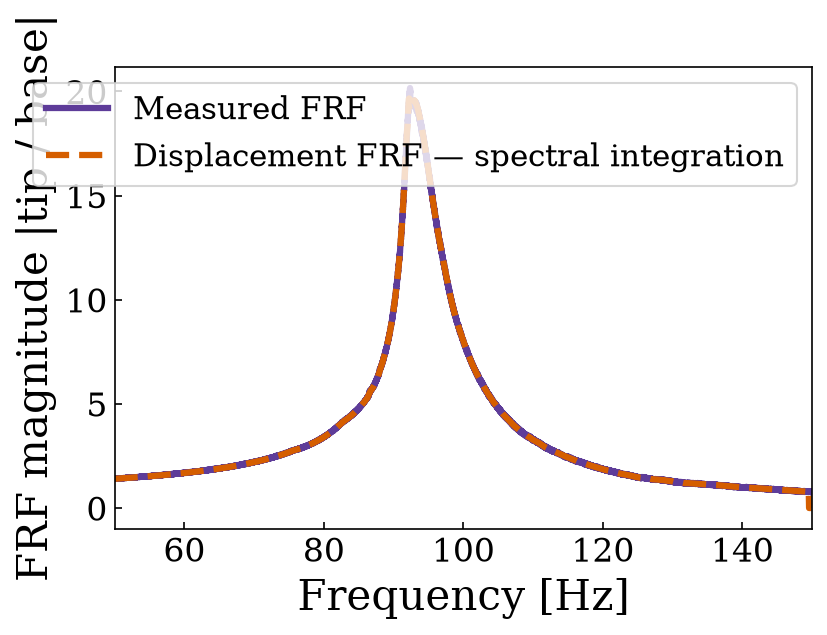

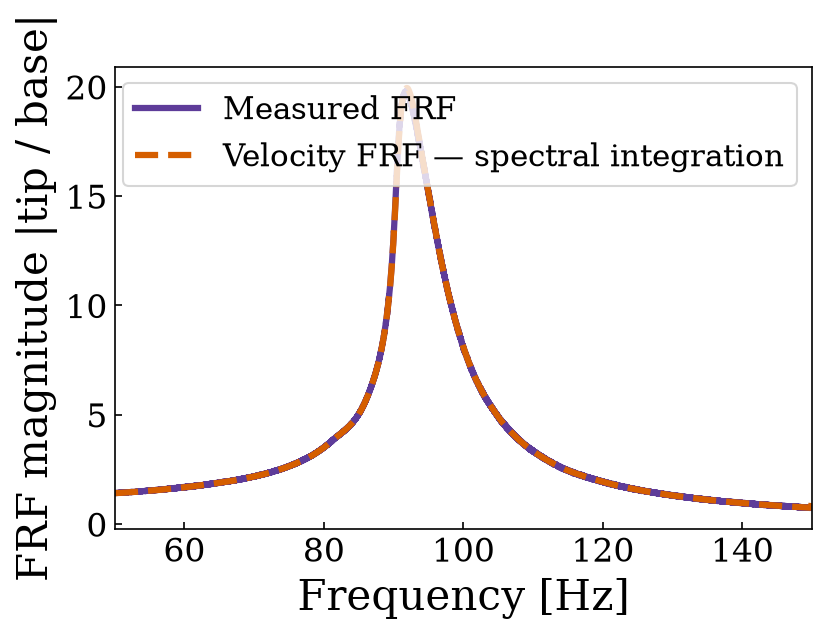

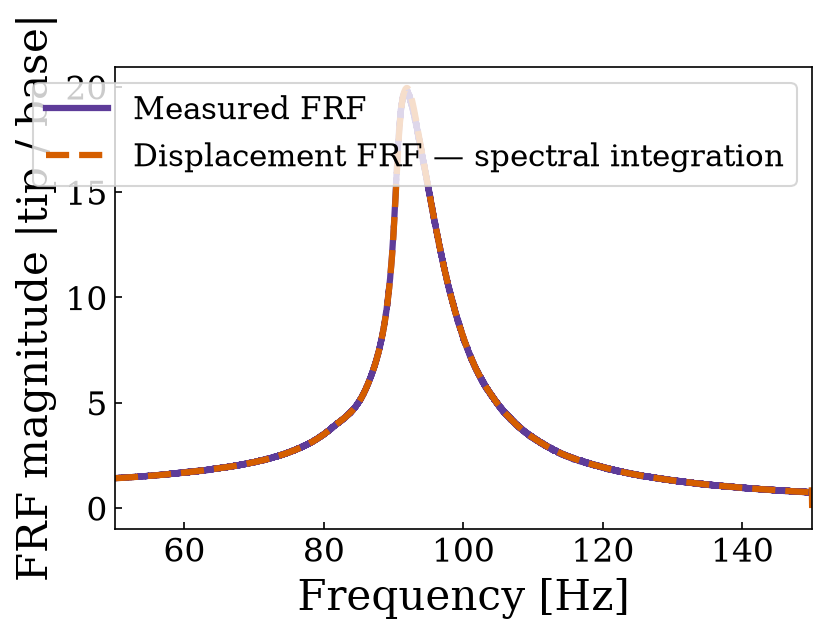

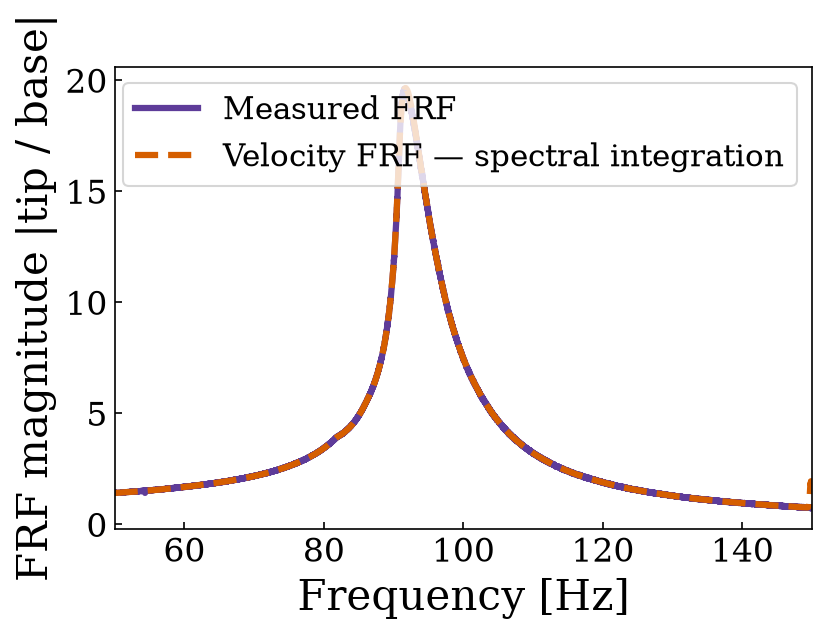

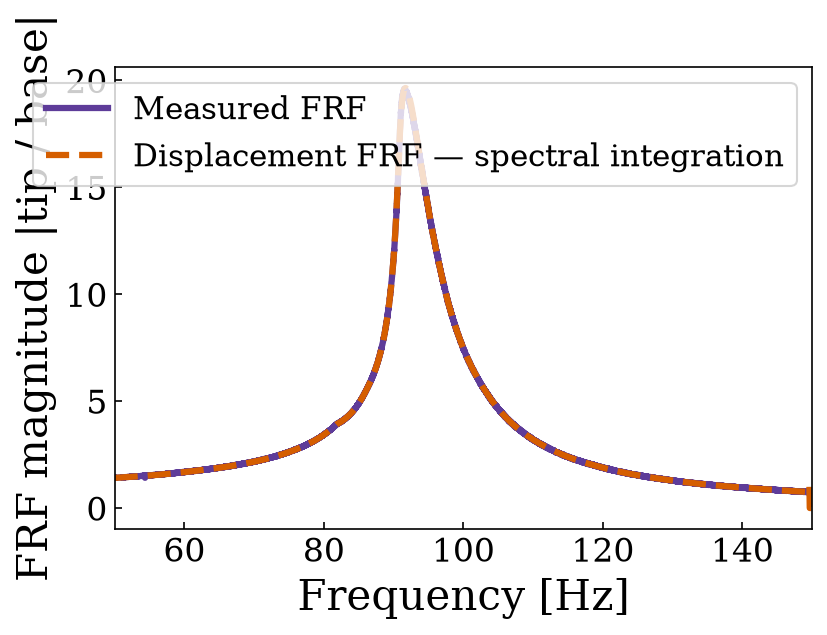

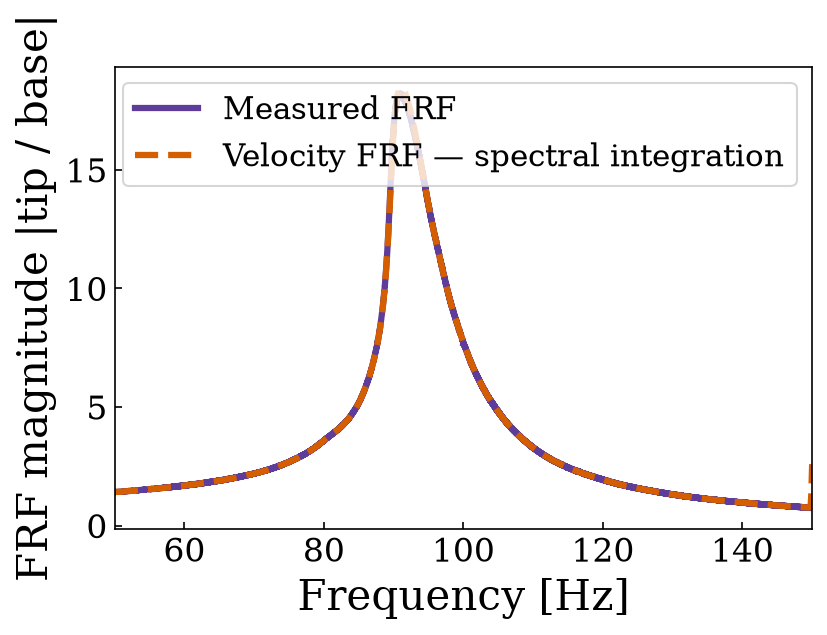

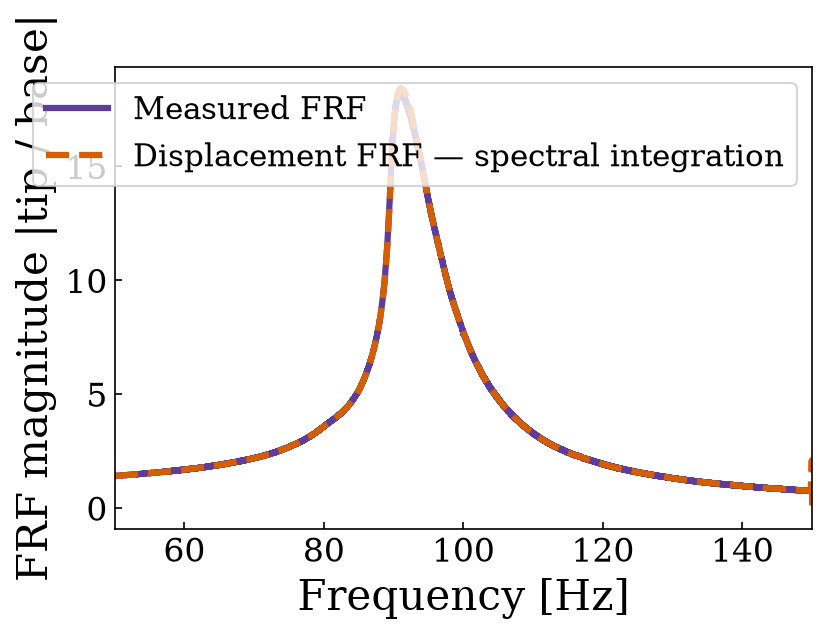

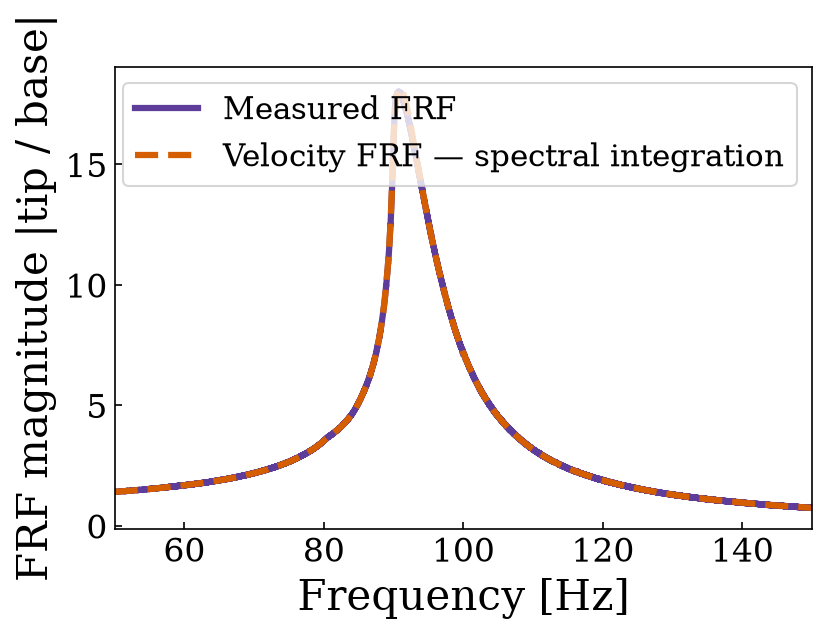

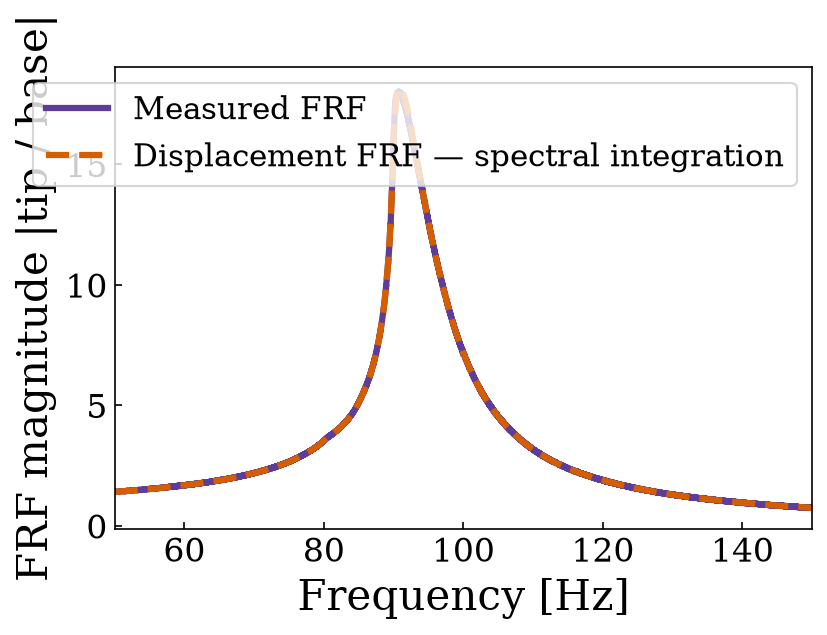

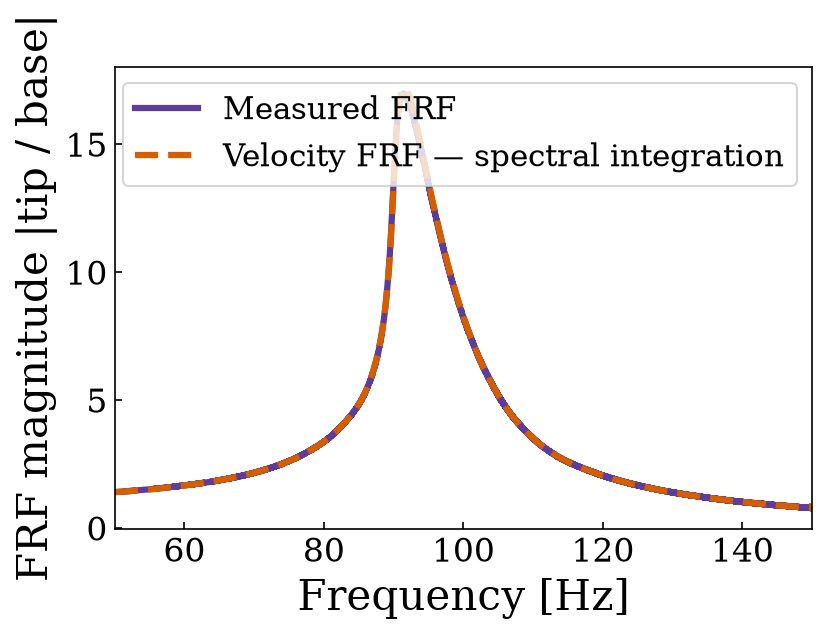

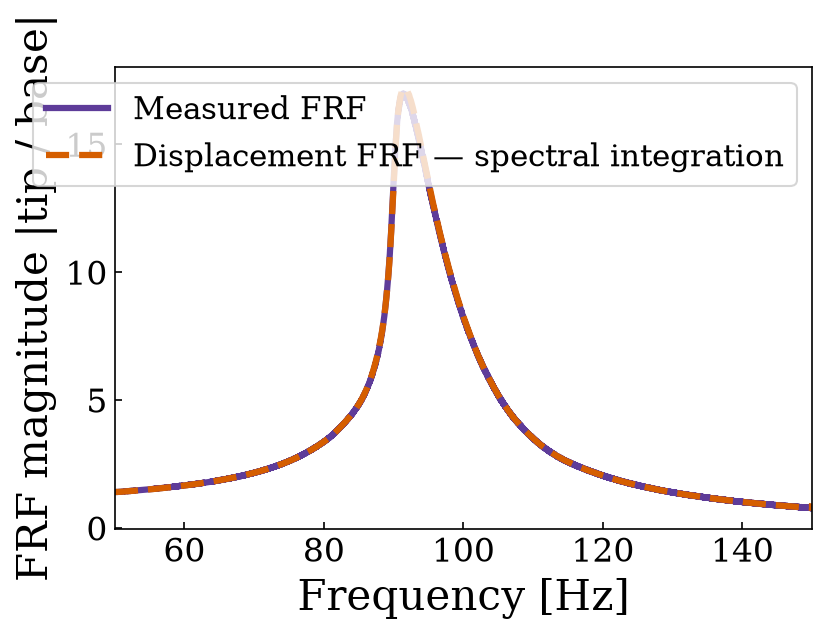

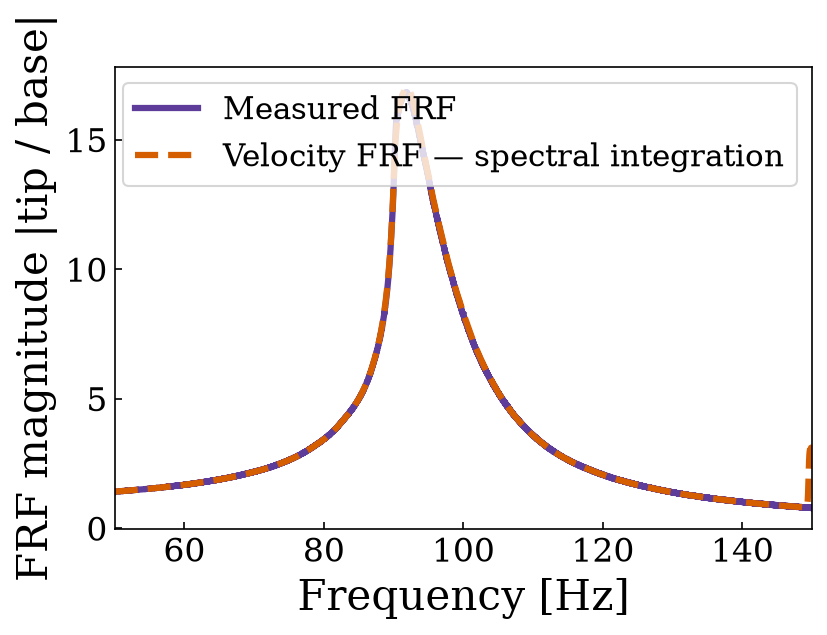

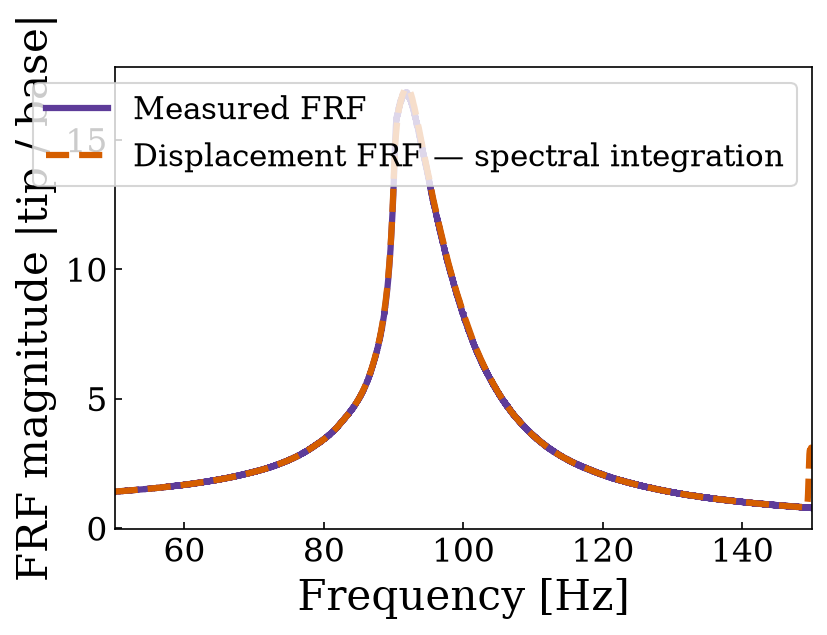

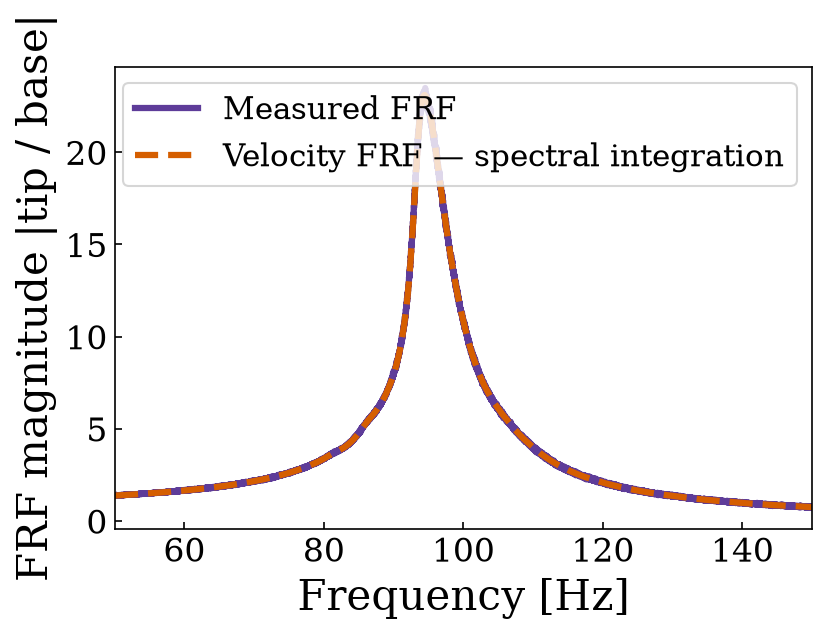

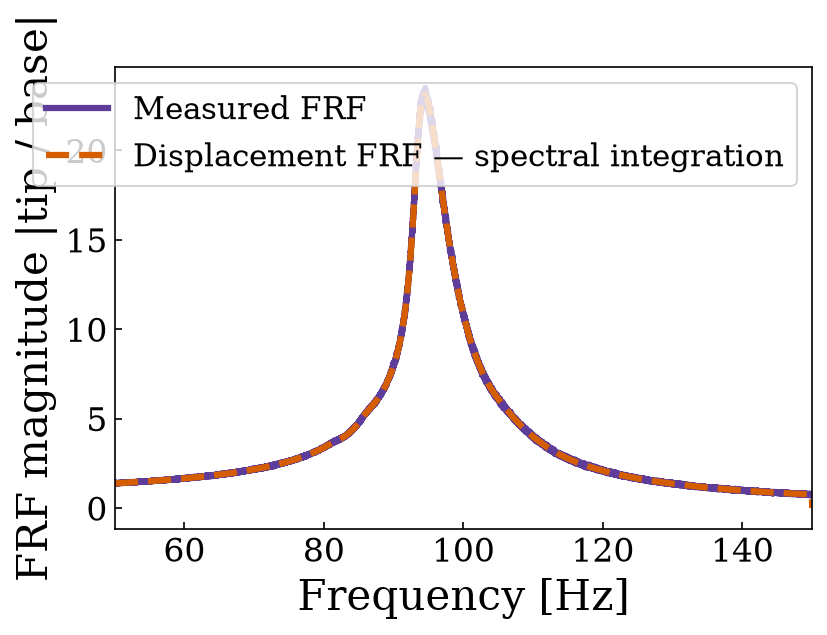

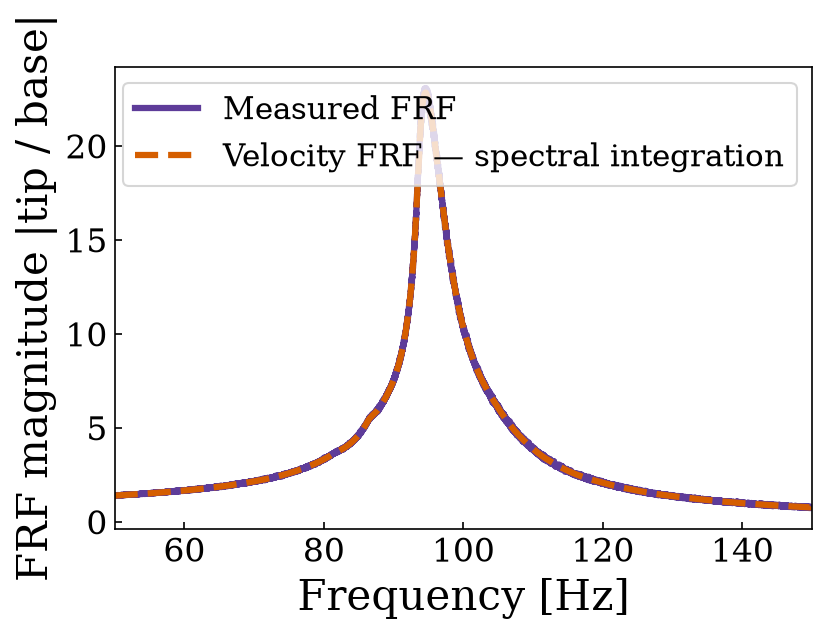

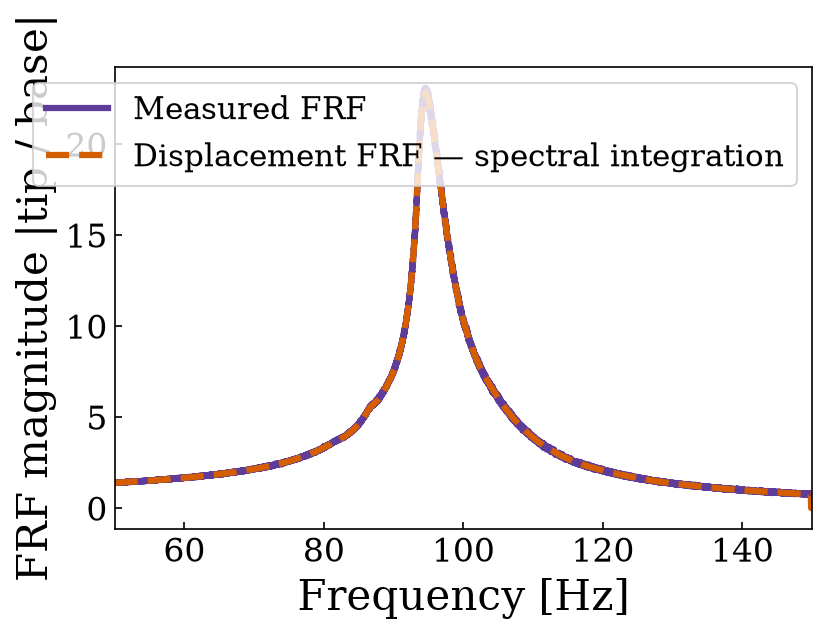

,signal,measured_peak_hz,velocity_frf_peak_hz,displacement_frf_peak_hz
0,relative_acceleration_000mA_1000mg_50-150_Hz_s...,92.889999,92.919922,92.919922
1,relative_acceleration_000mA_1000mg_50-150_Hz_s...,92.349998,92.236328,92.236328
2,relative_acceleration_000mA_1500mg_50-150_Hz_s...,91.970001,91.845703,91.845703
3,relative_acceleration_000mA_1500mg_50-150_Hz_s...,91.510002,91.699219,91.699219
4,relative_acceleration_000mA_2000mg_50-150_Hz_s...,90.910004,91.064453,91.064453
5,relative_acceleration_000mA_2000mg_50-150_Hz_s...,90.720001,90.917969,90.917969
6,relative_acceleration_000mA_2500mg_50-150_Hz_s...,91.370003,91.601562,91.601562
7,relative_acceleration_000mA_2500mg_50-150_Hz_s...,91.910004,91.699219,91.699219
8,relative_acceleration_000mA_500mg_50-150_Hz_sw...,94.529999,94.433594,94.433594
9,relative_acceleration_000mA_500mg_50-150_Hz_sw...,94.639999,94.580078,94.580078


In [58]:
def measured_frf_arrays(name):
    frf_name = name.replace("relative_acceleration", "FRF_ponta-base", 1)
    frf_name = frf_name.replace("sweep-up-down__sweep_up", "sweep-up")
    frf_name = frf_name.replace("sweep-up-down__sweep_down", "sweep-down")
    if frf_name not in data["FRF"]:
        raise KeyError(f"Measured FRF not found: {frf_name}")
    measured_frf = data["FRF"][frf_name]
    frequency, magnitude = measured_frf.x_values, measured_frf.y_values
    if hasattr(frequency, "values"):
        frequency = frequency.values
    if hasattr(magnitude, "values"):
        magnitude = magnitude.values
    frequency = np.asarray(frequency, dtype=float).squeeze()
    magnitude = np.abs(np.asarray(magnitude).squeeze())
    order = np.argsort(frequency)
    return frequency[order], magnitude[order]


frf_validation_rows = []
for name in signal_names:
    frf_signal = read_signal(name)
    fs_frf = 1.0 / np.median(np.diff(frf_signal["t"]))
    base_frf = frf_signal["base_acceleration"] - frf_signal["base_acceleration"].mean()
    tip_frf = frf_signal["tip_acceleration"] - frf_signal["tip_acceleration"].mean()
    _, _, base_velocity, base_displacement = integrate_spectral(base_frf, fs_frf)
    _, _, tip_velocity, tip_displacement = integrate_spectral(tip_frf, fs_frf)
    measured_frequency, measured_magnitude = measured_frf_arrays(name)
    velocity_frequency, velocity_magnitude = calculate_frf(base_velocity, tip_velocity, fs_frf)
    displacement_frequency, displacement_magnitude = calculate_frf(base_displacement, tip_displacement, fs_frf)
    measured_band = (measured_frequency >= MIN_BAND_HZ) & (measured_frequency <= MAX_BAND_HZ)
    frf_validation_rows.append({
        "signal": name,
        "measured_peak_hz": measured_frequency[measured_band][np.argmax(measured_magnitude[measured_band])],
        "velocity_frf_peak_hz": velocity_frequency[np.argmax(np.where(
            (velocity_frequency >= MIN_BAND_HZ) & (velocity_frequency <= MAX_BAND_HZ), velocity_magnitude, -np.inf))],
        "displacement_frf_peak_hz": displacement_frequency[np.argmax(np.where(
            (displacement_frequency >= MIN_BAND_HZ) & (displacement_frequency <= MAX_BAND_HZ), displacement_magnitude, -np.inf))],
    })
    for frequency, magnitude, label, tag in [
        (velocity_frequency, velocity_magnitude, "Velocity FRF — spectral integration", "velocity"),
        (displacement_frequency, displacement_magnitude, "Displacement FRF — spectral integration", "displacement"),
    ]:
        band = (frequency >= MIN_BAND_HZ) & (frequency <= MAX_BAND_HZ)
        plt.figure()
        plt.plot(measured_frequency[measured_band], measured_magnitude[measured_band], linewidth=3, alpha=1, label="Measured FRF")
        plt.plot(frequency[band], magnitude[band], "--", linewidth=3, alpha=1, label=label)
        plt.xlabel("Frequency [Hz]")
        plt.ylabel("FRF magnitude |tip / base|")
        plt.xlim(MIN_BAND_HZ, MAX_BAND_HZ)
        plt.legend()
        plt.savefig(FIGURES_DIR / f"frf_validation_{tag}_{slug(name)}.pdf")
        plt.show()
        plt.close()
display(pd.DataFrame(frf_validation_rows))

## Prepare all trajectories

Mean removal, high-pass filtering of base and relative accelerations, spectral integration of the relative acceleration.


In [59]:
def prepare_signal(name):
    signal = read_signal(name)
    time = signal["t"]
    sampling_frequency = 1.0 / np.median(np.diff(time))
    relative = signal["relative_acceleration"] - np.mean(signal["relative_acceleration"])
    base = signal["base_acceleration"] - np.mean(signal["base_acceleration"])
    filtered_relative = high_pass(relative, CUTOFF_HZ, sampling_frequency)
    filtered_base = high_pass(base, CUTOFF_HZ, sampling_frequency)
    _, _, spectral_velocity, spectral_displacement = integrate_spectral(
        relative, sampling_frequency
    )
    return {
        "name": name,
        "fs": sampling_frequency,
        "t": time - time[0],
        "u": filtered_base,
        "v_dot": filtered_relative,
        "x": spectral_displacement,
        "v": spectral_velocity,
        "x_dot": spectral_velocity,
    }

In [60]:
spectral_signals = []
for number, name in enumerate(signal_names, start=1):
    print(f"Preparing {number:02d}/{len(signal_names):02d}: {name}")
    spectral_signals.append(prepare_signal(name))
print("Preparation complete.")

Preparing 01/10: relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_down
Preparing 02/10: relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up
Preparing 03/10: relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_down
Preparing 04/10: relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_up
Preparing 05/10: relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_down
Preparing 06/10: relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_up
Preparing 07/10: relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_down
Preparing 08/10: relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_up
Preparing 09/10: relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_down
Preparing 10/10: relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_up
Preparation complete.


In [61]:
summary_rows = []
for prepared in spectral_signals:
    summary_rows.append(
        {
            "name": prepared["name"],
            "fs_hz": prepared["fs"],
            "samples": len(prepared["t"]),
            "duration_s": prepared["t"][-1],
            "u_rms_m_s2": np.sqrt(np.mean(prepared["u"] ** 2)),
            "v_dot_rms_m_s2": np.sqrt(np.mean(prepared["v_dot"] ** 2)),
            "v_rms_m_s": np.sqrt(np.mean(prepared["v"] ** 2)),
            "x_rms_m": np.sqrt(np.mean(prepared["x"] ** 2)),
        }
    )
summary = pd.DataFrame(summary_rows)
display(summary)

,name,fs_hz,samples,duration_s,u_rms_m_s2,v_dot_rms_m_s2,v_rms_m_s,x_rms_m
0,relative_acceleration_000mA_1000mg_50-150_Hz_s...,400.0,401377,1003.4400,6.927676,39.877634,0.066098,0.000111
1,relative_acceleration_000mA_1000mg_50-150_Hz_s...,400.0,401376,1003.4375,6.933959,38.339444,0.063528,0.000107
2,relative_acceleration_000mA_1500mg_50-150_Hz_s...,400.0,401377,1003.4400,10.388482,60.032826,0.100136,0.000170
3,relative_acceleration_000mA_1500mg_50-150_Hz_s...,400.0,401376,1003.4375,10.401515,57.264176,0.095386,0.000162
4,relative_acceleration_000mA_2000mg_50-150_Hz_s...,400.0,401408,1003.5175,13.843330,77.634745,0.129789,0.000221
5,relative_acceleration_000mA_2000mg_50-150_Hz_s...,400.0,401408,1003.5175,13.870812,74.604780,0.124602,0.000212
6,relative_acceleration_000mA_2500mg_50-150_Hz_s...,400.0,401377,1003.4400,17.312302,93.615357,0.155004,0.000262
7,relative_acceleration_000mA_2500mg_50-150_Hz_s...,400.0,401376,1003.4375,17.301118,94.069830,0.155680,0.000263
8,relative_acceleration_000mA_500mg_50-150_Hz_sw...,400.0,401408,1003.5175,3.466093,21.520165,0.035307,0.000059
9,relative_acceleration_000mA_500mg_50-150_Hz_sw...,400.0,401408,1003.5175,3.465596,20.775677,0.033988,0.000056


## Diagnostic fits

Exploratory fits on all ten experiments (NRMSE normalized by the target RMS).

In [62]:
def fit_least_squares(library, target):
    coefficients, _, _, _ = np.linalg.lstsq(a=library, b=target, rcond=None)
    prediction = library @ coefficients
    residual = target - prediction
    rmse = np.sqrt(np.mean(residual**2))
    target_rms = np.sqrt(np.mean(target**2))
    nrmse_percent = 100.0 * rmse / target_rms
    total_variation = np.sum((target - np.mean(target)) ** 2)
    residual_variation = np.sum(residual**2)
    r2 = 1.0 - residual_variation / total_variation
    result = {
        "coefficients": coefficients,
        "prediction": prediction,
        "residual": residual,
        "rmse": rmse,
        "nrmse_percent": nrmse_percent,
        "r2": r2,
    }
    return result


In [63]:
def maximum_absolute(values):
    maximum = np.max(np.abs(values))
    return maximum or 1.0


### Combined states


In [64]:
all_displacement = []
all_velocity = []
all_acceleration = []
for trajectory in spectral_signals:
    displacement = np.asarray(trajectory["x"], dtype=float)
    velocity = np.asarray(trajectory["v"], dtype=float)
    acceleration = np.asarray(trajectory["v_dot"], dtype=float) + np.asarray(
        trajectory["u"], dtype=float
    )
    if not np.isfinite([displacement, velocity, acceleration]).all():
        raise ValueError("Nonfinite states: no samples may be silently removed.")
    all_displacement.append(displacement)
    all_velocity.append(velocity)
    all_acceleration.append(acceleration)
delta_x = np.concatenate(all_displacement)
delta_v = np.concatenate(all_velocity)
tip_acceleration = np.concatenate(all_acceleration)
print(
    f"Maximum absolute displacement: {maximum_absolute(delta_x):.6e} m ({maximum_absolute(delta_x) * 1000.0:.6f} mm)"
)
print(f"Maximum absolute velocity: {maximum_absolute(delta_v):.6e} m/s")


Maximum absolute displacement: 1.276520e-03 m (1.276520 mm)
Maximum absolute velocity: 7.225685e-01 m/s


### Linear fit


In [65]:
all_linear_library = np.column_stack((delta_x, delta_v, np.ones(len(delta_x))))
all_linear_fit = fit_least_squares(all_linear_library, tip_acceleration)
linear_a = all_linear_fit["coefficients"][0]
linear_b = all_linear_fit["coefficients"][1]
linear_constant = all_linear_fit["coefficients"][2]
print(f"a_tip = {linear_a:.6e} delta_x {linear_b:+.6e} delta_v {linear_constant:+.6e}")
print(f"NRMSE = {all_linear_fit['nrmse_percent']:.2f}%")


a_tip = -3.434423e+05 delta_x -2.904756e+01 delta_v +9.657974e-05
NRMSE = 4.95%


### State projections


In [66]:
DISPLACEMENT_SMALL_LIMIT = 1e-07
VELOCITY_SMALL_LIMIT = 0.001
small_displacement = np.abs(delta_x) <= DISPLACEMENT_SMALL_LIMIT
velocity_plot = delta_v[small_displacement]
acceleration_velocity_plot = tip_acceleration[small_displacement]
full_x_ref = maximum_absolute(delta_x)
full_v_ref = maximum_absolute(delta_v)
full_a_ref = maximum_absolute(tip_acceleration)
print(f"Velocity-plane references: v_ref={full_v_ref:.6e} m/s, a_ref={full_a_ref:.6e} m/s²")


Velocity-plane references: v_ref=7.225685e-01 m/s, a_ref=4.485817e+02 m/s²


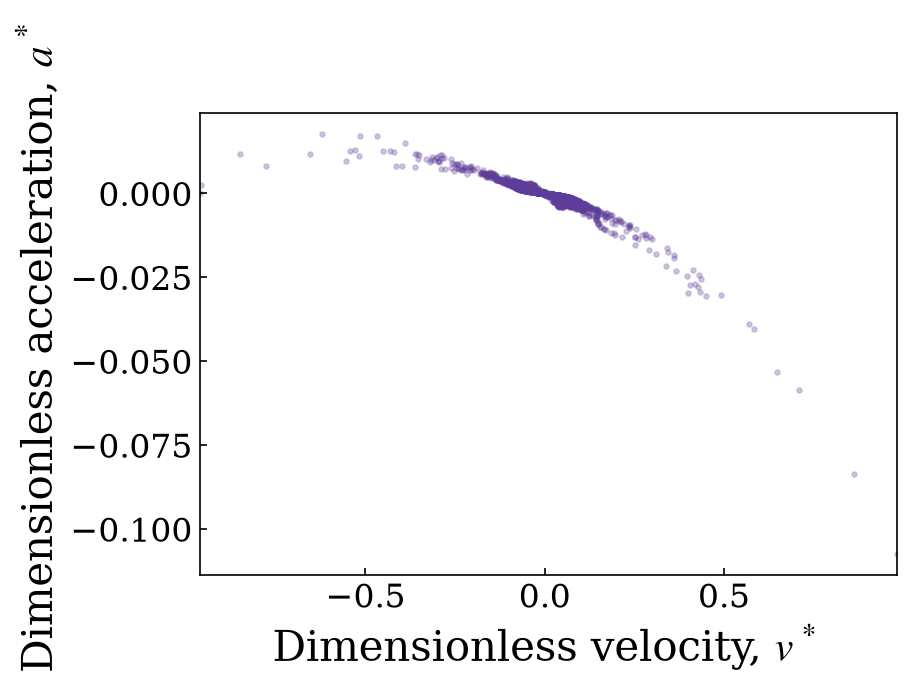

In [67]:
plt.figure()
plt.scatter(
    velocity_plot / full_v_ref,
    acceleration_velocity_plot / full_a_ref,
    s=5,
    alpha=0.25,
    rasterized=True,
)
plt.xlabel("Dimensionless velocity, $v^*$")
plt.ylabel("Dimensionless acceleration, $a^*$")
plt.savefig(FIGURES_DIR / "dimensionless_acceleration_velocity.pdf")
plt.show()


In [68]:
small_velocity = np.abs(delta_v) <= VELOCITY_SMALL_LIMIT
displacement_plot = delta_x[small_velocity]
acceleration_displacement_plot = tip_acceleration[small_velocity]
print(f"Displacement-plane references: x_ref={full_x_ref:.6e} m, a_ref={full_a_ref:.6e} m/s²")


Displacement-plane references: x_ref=1.276520e-03 m, a_ref=4.485817e+02 m/s²


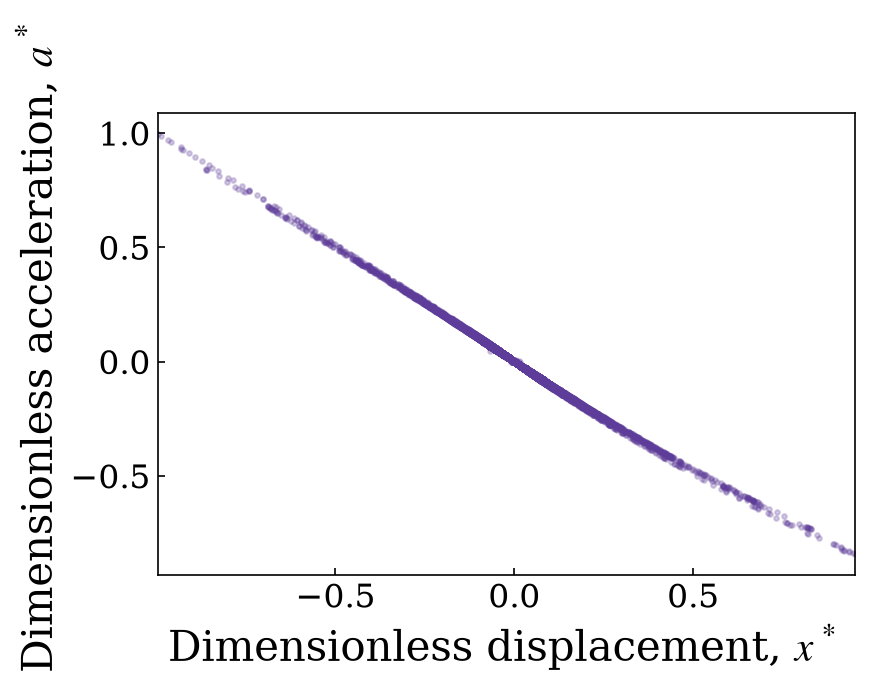

In [69]:
plt.figure()
plt.scatter(
    displacement_plot / full_x_ref,
    acceleration_displacement_plot / full_a_ref,
    s=5,
    alpha=0.25,
    rasterized=True,
)
plt.xlabel("Dimensionless displacement, $x^*$")
plt.ylabel("Dimensionless acceleration, $a^*$")
plt.savefig(FIGURES_DIR / "dimensionless_acceleration_displacement.pdf")
plt.show()


In [70]:
number_small_displacement = np.sum(small_displacement)
number_small_velocity = np.sum(small_velocity)
total_points = len(tip_acceleration)
print(f"Maximum absolute velocity: {full_v_ref:.6e} m/s")
print(f"Maximum absolute displacement: {full_x_ref:.6e} m ({full_x_ref * 1000.0:.6f} mm)")


Maximum absolute velocity: 7.225685e-01 m/s
Maximum absolute displacement: 1.276520e-03 m (1.276520 mm)


### Dimensionless residuals after subtracting the linear fit

Subtract the complete pooled linear fit, including its constant term, from the
processed experimental response acceleration:

$$r(t)=a_{\mathrm{tip}}(t)-\left(c_xx(t)+c_vv(t)+c_0\right).$$

Plot $r^*=r/\max|a_{\mathrm{tip}}|$ against
$v^*=v/\max|v|$ for $|x|\leq10^{-7}\,\mathrm{m}$, and against
$x^*=x/\max|x|$ for $|v|\leq10^{-3}\,\mathrm{m/s}$.
A 3D scatter of $r^*$ over the full $(x^*,v^*)$ plane, without cuts,
shows the residual structure across the whole state space.
All reference maxima are taken over the ten pooled trajectories, exactly as
in the preceding experimental-acceleration plots. In particular, the residual
uses the original acceleration reference, not its own maximum, so its size
can be compared directly with the preceding plots.

These are in-sample exploratory diagnostics of the pooled linear fit, not
held-out model errors. Curvature or structure reveals behavior that the linear
fit does not explain; it may include nonlinear effects, noise, reconstruction
effects and model mismatch. The cuts do not independently identify stiffness
or damping laws.


In [71]:
linear_acceleration_residual = np.asarray(all_linear_fit["residual"])
# The residual subtracts c_x*x + c_v*v + c_0, not just one linear contribution.
np.testing.assert_allclose(
    linear_acceleration_residual,
    tip_acceleration - all_linear_fit["prediction"],
    rtol=0.0,
    atol=0.0,
)
dimensionless_linear_residual = linear_acceleration_residual / full_a_ref
print("Residual definition: experimental tip acceleration minus the pooled linear fit")
print(f"Acceleration reference (all experiments): {full_a_ref:.6e} m/s^2")
print(f"Velocity-cut samples: {np.count_nonzero(small_displacement)}")
print(f"Displacement-cut samples: {np.count_nonzero(small_velocity)}")


Residual definition: experimental tip acceleration minus the pooled linear fit
Acceleration reference (all experiments): 4.485817e+02 m/s^2
Velocity-cut samples: 8734
Displacement-cut samples: 83880


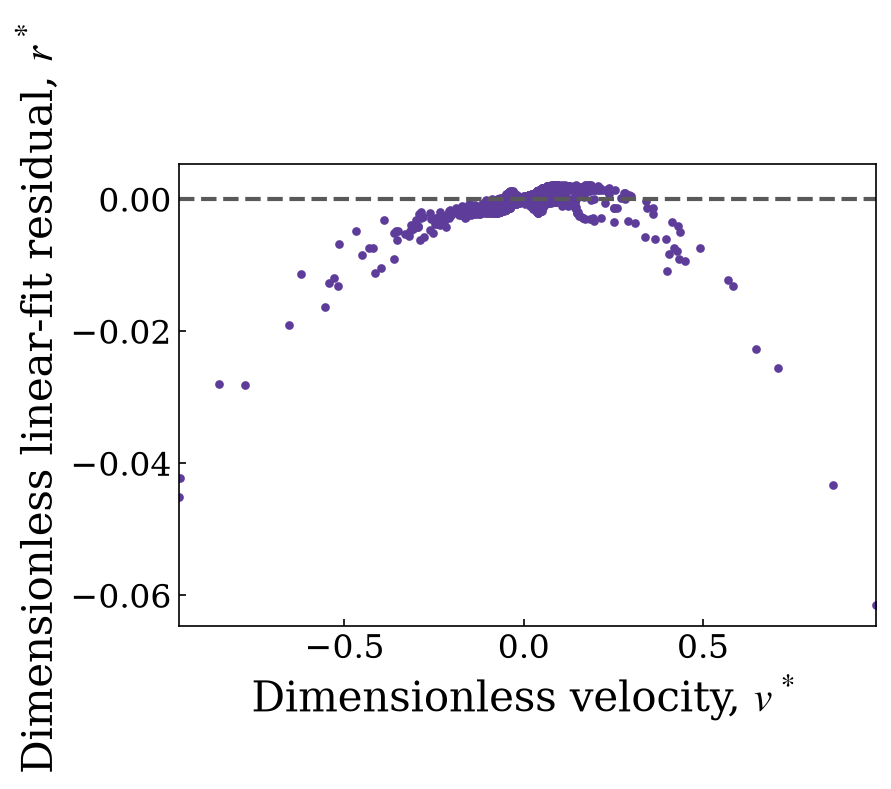

In [80]:
figure, axis = plt.subplots()
axis.scatter(
    delta_v[small_displacement] / full_v_ref,
    dimensionless_linear_residual[small_displacement],
    s=10,
    alpha=1,
    rasterized=True,
)
axis.axhline(0.0, color="0.35", linestyle="--", linewidth=2)
axis.set_xlabel("Dimensionless velocity, $v^*$")
axis.set_ylabel("Dimensionless linear-fit residual, $r^*$")
figure.savefig(FIGURES_DIR / "dimensionless_linear_residual_velocity.pdf")
plt.show()
plt.close(figure)


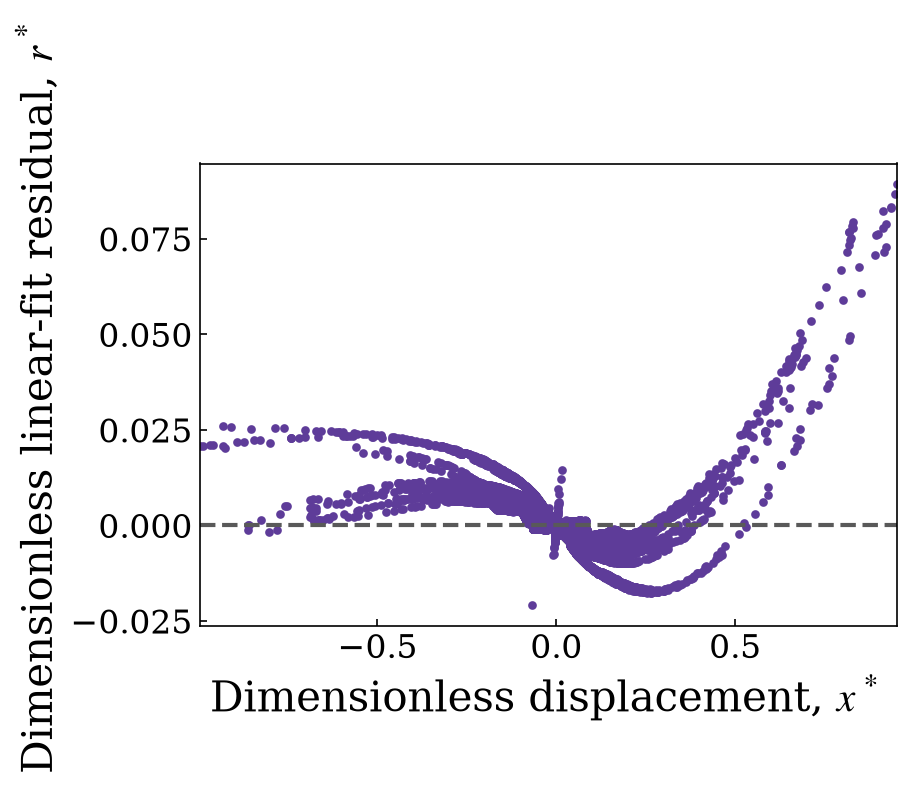

In [81]:
figure, axis = plt.subplots()
axis.scatter(
    delta_x[small_velocity] / full_x_ref,
    dimensionless_linear_residual[small_velocity],
    s=10,
    alpha=1,
    rasterized=True,
)
axis.axhline(0.0, color="0.35", linestyle="--", linewidth=2)
axis.set_xlabel("Dimensionless displacement, $x^*$")
axis.set_ylabel("Dimensionless linear-fit residual, $r^*$")
figure.savefig(FIGURES_DIR / "dimensionless_linear_residual_displacement.pdf")
plt.show()
plt.close(figure)


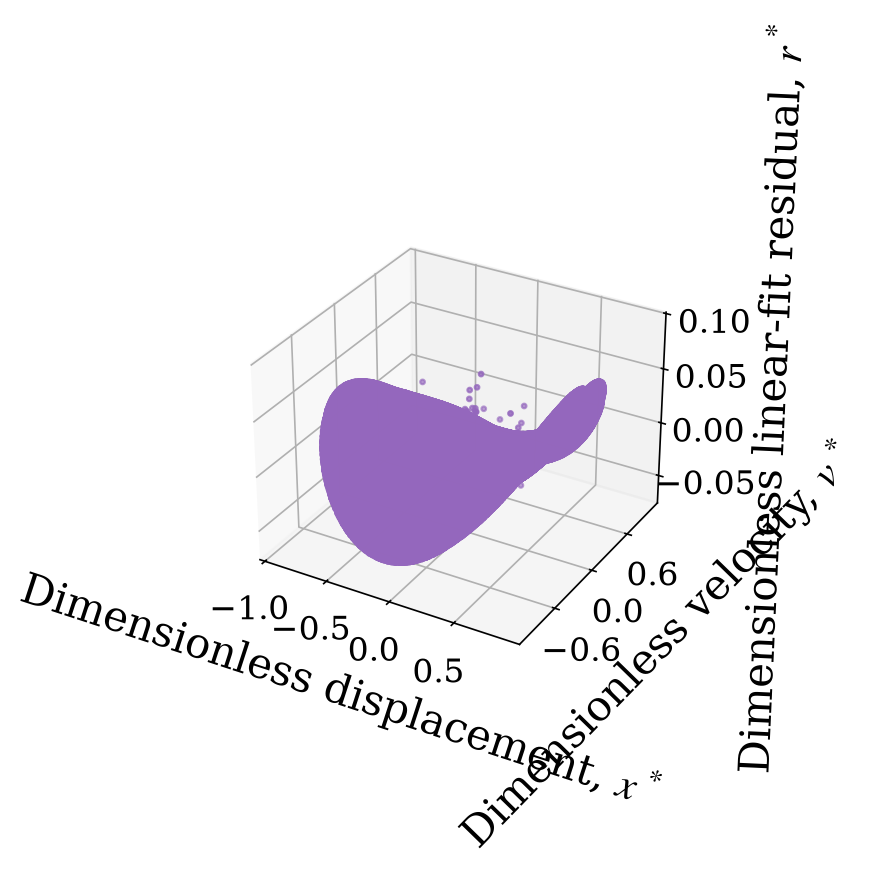

In [82]:
from matplotlib.ticker import MaxNLocator

figure = plt.figure()
axis = figure.add_subplot(projection="3d")
axis.scatter(
    delta_x / full_x_ref,
    delta_v / full_v_ref,
    dimensionless_linear_residual,
    color="tab:purple",
    s=5,
    alpha=1,
    rasterized=True,
)
for coordinate_axis in (axis.xaxis, axis.yaxis, axis.zaxis):
    coordinate_axis.set_major_locator(MaxNLocator(nbins=4))
axis.tick_params(axis="z", pad=6)
axis.set_xlabel("Dimensionless displacement, $x^*$", labelpad=10)
axis.set_ylabel("Dimensionless velocity, $v^*$", labelpad=10)
axis.set_zlabel("Dimensionless linear-fit residual, $r^*$", labelpad=12)
figure.savefig(FIGURES_DIR / "dimensionless_linear_residual_3d.pdf", bbox_inches="tight")
plt.show()
plt.close(figure)


## Train/test diagnostic comparisons

Preview of the evaluation protocol: three simple models fitted on the training levels and evaluated on every experiment.

In [75]:
# Shared protocol: TEST_LEVEL_MG (both sweeps) is the test set; the other levels train.
# Predictions are made at the measured states; NRMSE = RMSE / std(measured).
LEVELS_MG = (500, 1000, 1500, 2000, 2500)
TEST_LEVEL_MG = 1500
TRAINING_LEVELS_MG = tuple(level for level in LEVELS_MG if level != TEST_LEVEL_MG)
ROLES = ("train", "test")
PROTOCOL_DESCRIPTION = (f"single train/test split: test level {TEST_LEVEL_MG} mg; "
                        f"training levels {TRAINING_LEVELS_MG} mg")
SWEEP_MIN_HZ, SWEEP_MAX_HZ = 50.0, 150.0
RESONANCE_BAND_HZ = (80.0, 110.0)
# Selection score on the training set: TOTAL_ERROR_WEIGHT * NRMSE
# + RESONANCE_ERROR_WEIGHT * resonance-band NRMSE. The smallest model within
# ACCEPTABLE_ERROR_INCREASE of the best score is selected.
TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT = 0.3, 0.7
ACCEPTABLE_ERROR_INCREASE = 0.1


def excitation_level_mg(name):
    return int(re.search(r"(\d+)mg", str(name)).group(1))


def sweep_direction(name):
    return "down" if "sweep_down" in str(name) else "up"


def sweep_frequency_hz(name, t):
    """Nominal frequency, assuming a linear sweep."""
    fraction = (t - t[0]) / (t[-1] - t[0])
    if sweep_direction(name) == "down":
        return SWEEP_MAX_HZ - fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)
    return SWEEP_MIN_HZ + fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)


def resonance_band_mask(name, t):
    """Samples whose nominal sweep frequency lies in the resonance band."""
    frequency = sweep_frequency_hz(name, t)
    return (frequency >= RESONANCE_BAND_HZ[0]) & (frequency <= RESONANCE_BAND_HZ[1])


def signal_role(name):
    """Split role of an experiment: 'test' at the test level, 'train' otherwise."""
    return "test" if excitation_level_mg(name) == TEST_LEVEL_MG else "train"


def check_signals(signals, require_all_levels=True):
    names = [s["name"] for s in signals]
    if len(set(names)) != len(names):
        raise ValueError("Signal names must be unique.")
    found = {}
    for signal in signals:
        level = excitation_level_mg(signal["name"])
        if level not in LEVELS_MG:
            raise ValueError(f"Unknown excitation level: {signal['name']}")
        found.setdefault(level, []).append(sweep_direction(signal["name"]))
        arrays = [np.asarray(signal[k], dtype=float).reshape(-1) for k in ("t", "x", "v", "u", "v_dot")]
        if len({len(a) for a in arrays}) != 1 or len(arrays[0]) < 2:
            raise ValueError(f"Mismatched array lengths: {signal['name']}")
        if not all(np.isfinite(a).all() for a in arrays):
            raise ValueError(f"Nonfinite data: {signal['name']}")
        if np.any(np.diff(arrays[0]) <= 0):
            raise ValueError(f"Time must increase: {signal['name']}")
    for level in (LEVELS_MG if require_all_levels else found):
        if sorted(found.get(level, [])) != ["down", "up"]:
            raise ValueError(f"Level {level} mg needs exactly one upward and one downward sweep.")
    return sorted(signals, key=lambda s: (excitation_level_mg(s["name"]), s["name"]))


def split_signals(signals):
    """Single train/test split by excitation level."""
    signals = check_signals(signals)
    return {"test_level_mg": TEST_LEVEL_MG, "fit_levels_mg": TRAINING_LEVELS_MG,
            "fit": [s for s in signals if signal_role(s["name"]) == "train"],
            "test": [s for s in signals if signal_role(s["name"]) == "test"]}


def split_table(split):
    rows = []
    for role, key, levels in (("train", "fit", split["fit_levels_mg"]),
                              ("test", "test", (split["test_level_mg"],))):
        rows.append({"role": role, "levels_mg": tuple(levels), "experiments": len(split[key]),
                     "samples": sum(len(s["t"]) for s in split[key])})
    return pd.DataFrame(rows)


def scores(measured, predicted, resonance_mask, weights):
    residual = measured - predicted
    rmse = np.sqrt(np.mean(residual ** 2))
    nrmse = rmse / np.std(measured)
    r2 = 1.0 - np.sum(residual ** 2) / np.sum((measured - np.mean(measured)) ** 2)
    resonance = (np.sqrt(np.mean(residual[resonance_mask] ** 2))
                 / np.std(measured[resonance_mask]))
    return {"total_RMSE": rmse, "total_NRMSE": nrmse, "total_R2": r2,
            "resonance_NRMSE": resonance,
            "weighted_score": weights[0] * nrmse + weights[1] * resonance}


def build_series(signals):
    series = {}
    for signal in check_signals(signals, require_all_levels=False):
        name = signal["name"]
        t, x, v, u, measured = (np.asarray(signal[k], dtype=float).reshape(-1)
                                for k in ("t", "x", "v", "u", "v_dot"))
        series[name] = {
            "level_mg": excitation_level_mg(name), "sweep": sweep_direction(name),
            "role": signal_role(name),
            "time": t - t[0], "x": x, "v": v, "input": u,
            "experimental_acceleration": measured,
            "instantaneous_frequency_hz": sweep_frequency_hz(name, t),
            "resonance_mask": resonance_band_mask(name, t),
            "model_predictions": {},
        }
    return series


def add_predictions(series, model_functions, names=None):
    """Store each model's predictions under the role of each experiment (or only `names`)."""
    for name, record in series.items():
        if names is not None and name not in names:
            continue
        x, v, u = record["x"], record["v"], record["input"]
        for model_name, function in model_functions.items():
            predicted = np.broadcast_to(np.asarray(function(x, v, u), dtype=float),
                                        record["experimental_acceleration"].shape).astype(float)
            if not np.isfinite(predicted).all():
                raise ValueError(f"Nonfinite prediction: {model_name} on {name}")
            record["model_predictions"].setdefault(model_name, {})[record["role"]] = predicted
    return series


def summarize_models(series, weights=(TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT)):
    """Metric tables per signal, per level and per role (train/test, pooled)."""
    per_signal, models = [], []
    for name, record in series.items():
        for model, roles in record["model_predictions"].items():
            if model not in models:
                models.append(model)
            for role, predicted in roles.items():
                per_signal.append({
                    "signal": name, "level_mg": record["level_mg"], "sweep": record["sweep"],
                    "model": model, "role": role,
                    **scores(record["experimental_acceleration"], predicted,
                             record["resonance_mask"], weights)})
    per_level, aggregate = [], []
    for model in models:
        names = [n for n, r in series.items() if model in r["model_predictions"]]

        def pooled(group):
            measured = np.concatenate([series[n]["experimental_acceleration"] for n in group])
            mask = np.concatenate([series[n]["resonance_mask"] for n in group])
            predicted = np.concatenate([series[n]["model_predictions"][model][series[n]["role"]]
                                        for n in group])
            return {"signals": len(group), "samples": len(measured),
                    **scores(measured, predicted, mask, weights)}

        for level in sorted({series[n]["level_mg"] for n in names}):
            group = [n for n in names if series[n]["level_mg"] == level]
            per_level.append({"level_mg": level, "role": series[group[0]]["role"],
                              "model": model, **pooled(group)})
        for role in ROLES:
            group = [n for n in names if series[n]["role"] == role]
            if group:
                aggregate.append({"model": model, "role": role,
                                  "levels_mg": tuple(sorted({series[n]["level_mg"] for n in group})),
                                  **pooled(group)})
    return (pd.DataFrame(per_signal), pd.DataFrame(per_level), pd.DataFrame(aggregate))


def regression_block(library, target, resonance_mask):
    """Library, target and resonance mask of one experiment (all samples)."""
    library = np.asarray(library, dtype=float)
    target = np.asarray(target, dtype=float).reshape(-1)
    resonance_mask = np.asarray(resonance_mask, dtype=bool).reshape(-1)
    if library.shape[0] != len(target) or len(resonance_mask) != len(target):
        raise ValueError("Library, target and resonance mask must have the same number of samples.")
    return {"Theta": library, "y": target, "resonance_mask": resonance_mask, "samples": len(target)}


def coefficient_scores(theta, blocks):
    """Pooled NRMSE, resonance-band NRMSE and selection score of a coefficient vector."""
    residual = np.concatenate([b["y"] - b["Theta"] @ theta for b in blocks])
    measured = np.concatenate([b["y"] for b in blocks])
    mask = np.concatenate([b["resonance_mask"] for b in blocks])
    total = np.sqrt(np.mean(residual ** 2)) / np.std(measured)
    resonance = np.sqrt(np.mean(residual[mask] ** 2)) / np.std(measured[mask])
    return {"nrmse": total, "resonance_nrmse": resonance,
            "score": TOTAL_ERROR_WEIGHT * total + RESONANCE_ERROR_WEIGHT * resonance}


def within_tolerance(results, score_column="training_score"):
    """Rows whose score is within ACCEPTABLE_ERROR_INCREASE of the best finite score."""
    finite = results[np.isfinite(results[score_column])]
    limit = finite[score_column].min() * (1.0 + ACCEPTABLE_ERROR_INCREASE) + 1e-14
    return finite[finite[score_column] <= limit]


In [76]:
# Line styles: solid = test, dashed = train.
ROLE_STYLES = {"train": "--", "test": "-"}
ROLE_LABELS = {"train": "Train", "test": "Test"}


def plot_diagnostics(series, folder):
    scales = {}
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    for name, record in series.items():
        label = f"{record['level_mg']} mg, sweep {record['sweep']}"
        time, x, v, u = record["time"], record["x"], record["v"], record["input"]
        measured, mask = record["experimental_acceleration"], record["resonance_mask"]
        predictions = [(model, role, predicted)
                       for model, roles in record["model_predictions"].items()
                       for role, predicted in roles.items()]
        tip = measured + u
        x_scale, v_scale, tip_scale = (max(np.max(np.abs(a)), np.finfo(float).eps)
                                       for a in (x, v, tip))
        scales[name] = {"x_scale": x_scale, "v_scale": v_scale, "a_tip_scale": tip_scale,
                        "level_mg": record["level_mg"], "comparison_points": len(x),
                        "normalization": "maximum absolute experimental value"}

        for window, tag in [(slice(None), "time"), (mask, "resonance")]:
            fig, ax = plt.subplots()
            ax.plot(time[window], measured[window], color="k", lw=1.0, alpha=0.6,
                    label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.plot(time[window], predicted[window], ROLE_STYLES[role], lw=0.4,
                        alpha=0.55, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel("Time [s]")
            ax.set_ylabel("Relative acceleration [m/s$^2$]")
            ax.legend(loc="upper right")
            fig.savefig(folder / f"one_step_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)

        fig, ax = plt.subplots()
        for model, role, predicted in predictions:
            ax.scatter(measured, predicted, s=2, alpha=0.2, rasterized=True,
                       label=f"{model} ({ROLE_LABELS[role]})")
        limits = [float(measured.min()), float(measured.max())]
        ax.plot(limits, limits, "k--", lw=1.0, label=f"Ideal - {label}")
        ax.set_xlabel("Measured $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.set_ylabel("Predicted $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.legend(loc="upper left")
        fig.savefig(folder / f"one_step_parity_{slug(name)}.pdf", format="pdf")
        plt.show()
        plt.close(fig)

        cuts = [(v, v_scale, np.abs(x / x_scale) <= 1e-3, "velocity, $v^*$", "velocity"),
                (x, x_scale, np.abs(v / v_scale) <= 1e-3, "displacement, $x^*$", "displacement")]
        for axis, scale, cut, axis_label, tag in cuts:
            fig, ax = plt.subplots()
            ax.scatter(axis[cut] / scale, tip[cut] / tip_scale, s=9, color="k", alpha=0.5,
                       rasterized=True, label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.scatter(axis[cut] / scale, (predicted + u)[cut] / tip_scale, s=7,
                           alpha=0.5, rasterized=True, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel(f"Dimensionless {axis_label}")
            ax.set_ylabel("Dimensionless tip acceleration, $a_{\\mathrm{tip}}^*$")
            ax.legend(loc="upper left")
            fig.savefig(folder / f"dimensionless_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)
    return scales


def plot_level_metrics(per_level, metric, ylabel, filename):
    table = per_level.assign(label=per_level["model"] + " (" + per_level["role"].map(ROLE_LABELS) + ")")
    table = table.pivot(index="level_mg", columns="label", values=metric)
    fig, ax = plt.subplots()
    table.plot.bar(ax=ax)
    ax.set(xlabel="Excitation level [mg]", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7)
    fig.savefig(filename)
    plt.show()
    plt.close(fig)
    return table

,role,levels_mg,experiments,samples
0,train,"(500, 1000, 2000, 2500)",8,3211138
1,test,"(1500,)",2,802753


,signal,level_mg,sweep,model,role,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,Linear,train,1.045951,0.048603,0.997638,0.045430,0.047017
1,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,Cubic displacement,train,0.678628,0.031535,0.999006,0.024543,0.028039
2,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,Quadratic velocity,train,1.082737,0.050313,0.997469,0.045204,0.047758
3,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,Linear,train,1.040674,0.050091,0.997491,0.047139,0.048615
4,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,Cubic displacement,train,0.669409,0.032221,0.998962,0.025282,0.028751
5,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,Quadratic velocity,train,1.079240,0.051947,0.997301,0.046997,0.049472
6,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,Linear,train,1.318953,0.033075,0.998906,0.029416,0.031245
7,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,Cubic displacement,train,1.055212,0.026461,0.999300,0.023445,0.024953
8,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,Quadratic velocity,train,1.280865,0.032120,0.998968,0.027240,0.029680
9,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,Linear,train,1.143075,0.029815,0.999111,0.026177,0.027996


,level_mg,role,model,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,500,train,Linear,2,802816,1.043316,0.049327,0.997567,0.046260,0.047793
1,1000,train,Linear,2,802753,1.234151,0.031551,0.999005,0.027911,0.029731
2,1500,test,Linear,2,802753,2.279586,0.038858,0.998490,0.036878,0.037868
3,2000,train,Linear,2,802816,3.689461,0.048460,0.997652,0.048045,0.048252
4,2500,train,Linear,2,802753,4.957719,0.052830,0.997209,0.050809,0.051819
5,500,train,Cubic displacement,2,802816,0.674034,0.031867,0.998984,0.024901,0.028384
6,1000,train,Cubic displacement,2,802753,0.986249,0.025213,0.999364,0.022200,0.023707
7,1500,test,Cubic displacement,2,802753,1.933588,0.032960,0.998914,0.032209,0.032585
8,2000,train,Cubic displacement,2,802816,2.840584,0.037310,0.998608,0.037343,0.037326
9,2500,train,Cubic displacement,2,802753,3.767417,0.040146,0.998388,0.039015,0.039580


,model,role,levels_mg,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,Linear,train,"(500, 1000, 2000, 2500)",8,3211138,3.193833,0.049607,0.997539,0.048014,0.048811
1,Linear,test,"(1500,)",2,802753,2.279586,0.038858,0.998490,0.036878,0.037868
2,Cubic displacement,train,"(500, 1000, 2000, 2500)",8,3211138,2.433572,0.037799,0.998571,0.036831,0.037315
3,Cubic displacement,test,"(1500,)",2,802753,1.933588,0.032960,0.998914,0.032209,0.032585
4,Quadratic velocity,train,"(500, 1000, 2000, 2500)",8,3211138,2.898691,0.045023,0.997973,0.042481,0.043752
5,Quadratic velocity,test,"(1500,)",2,802753,2.095945,0.035727,0.998724,0.032878,0.034303


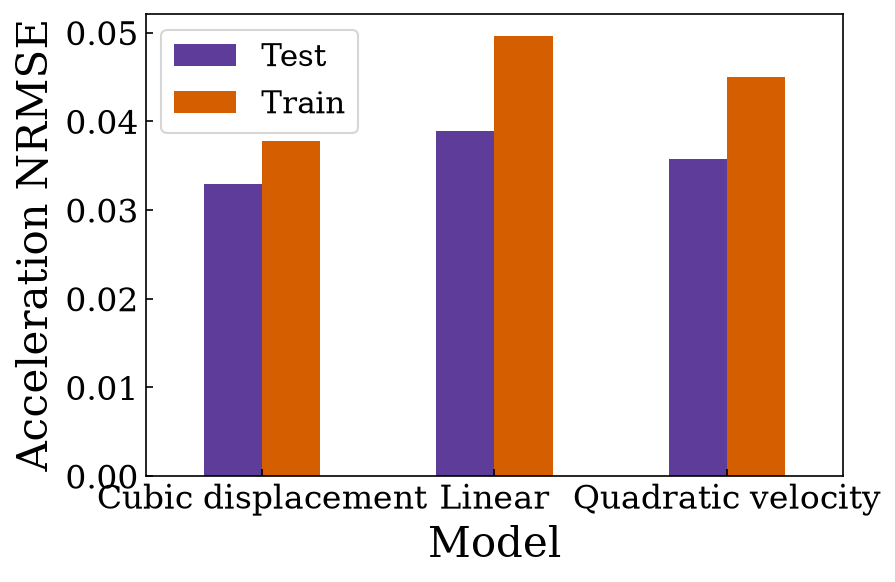

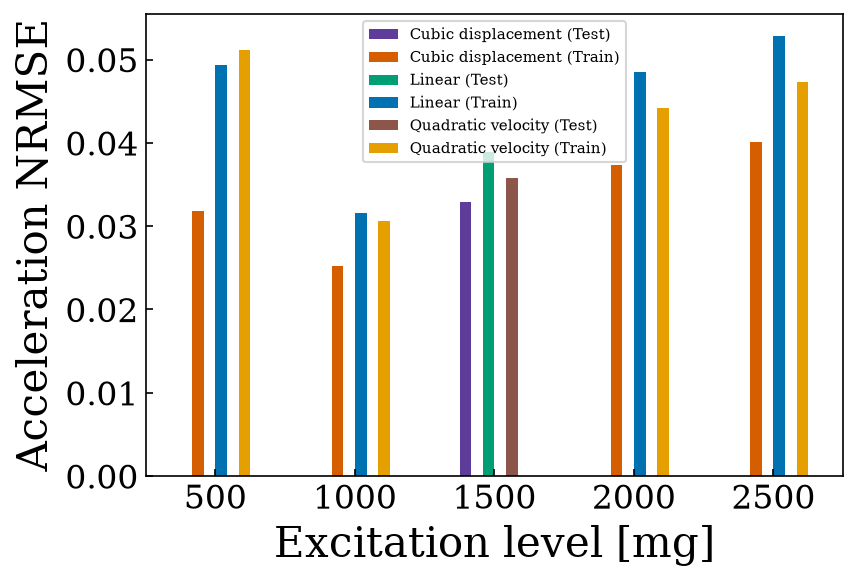

label,Cubic displacement (Test),Cubic displacement (Train),Linear (Test),Linear (Train),Quadratic velocity (Test),Quadratic velocity (Train)
level_mg,,,,,,
500,NaN,0.031867,NaN,0.049327,NaN,0.051108
1000,NaN,0.025213,NaN,0.031551,NaN,0.030645
1500,0.03296,NaN,0.038858,NaN,0.035727,NaN
2000,NaN,0.037310,NaN,0.048460,NaN,0.044166
2500,NaN,0.040146,NaN,0.052830,NaN,0.047294


In [77]:
all_signals = check_signals(spectral_signals)
diagnostic_split = split_signals(all_signals)
display(split_table(diagnostic_split))


def diagnostic_library(x, v, kind):
    if kind == "Linear":
        return np.column_stack((x, v, np.ones_like(x)))
    if kind == "Cubic displacement":
        return np.column_stack((x, x**2, x**3, v, np.ones_like(x)))
    return np.column_stack((x, v, v**2, np.ones_like(x)))


def fit_diagnostic(signals, kind):
    library = np.vstack([diagnostic_library(s["x"], s["v"], kind) for s in signals])
    target = np.concatenate(
        [np.asarray(s["v_dot"]).ravel() + np.asarray(s["u"]).ravel() for s in signals]
    )
    scale = np.sqrt(np.mean(library**2, axis=0))
    scale[scale == 0] = 1.0
    theta = np.linalg.lstsq(library / scale, target, rcond=None)[0] / scale
    # the model predicts the relative acceleration, hence the "- u"
    return theta, (lambda x, v, u, kind=kind, theta=theta: diagnostic_library(x, v, kind) @ theta - u)


DIAGNOSTIC_KINDS = ("Linear", "Cubic displacement", "Quadratic velocity")
processing_series = build_series(all_signals)
diagnostic_coefficients, functions = {}, {}
for kind in DIAGNOSTIC_KINDS:
    diagnostic_coefficients[kind], functions[kind] = fit_diagnostic(diagnostic_split["fit"], kind)
add_predictions(processing_series, functions)
processing_metrics, processing_per_level, processing_aggregate = summarize_models(processing_series)
display(processing_metrics)
display(processing_per_level)
display(processing_aggregate)
fig, ax = plt.subplots()
processing_aggregate.pivot(index="model", columns="role", values="total_NRMSE").rename(columns=ROLE_LABELS).rename_axis(columns=None).plot.bar(ax=ax)
ax.set(xlabel="Model", ylabel="Acceleration NRMSE")
ax.tick_params(axis="x", rotation=0)
fig.savefig(FIGURES_DIR / "one_step_role_metrics.pdf")
plt.show()
plot_level_metrics(processing_per_level, "total_NRMSE", "Acceleration NRMSE",
                   FIGURES_DIR / "one_step_level_metrics.pdf")


## Save the results


In [78]:
processing_metadata = {
    "source_data_file": str(DATA_FILE.resolve()),
    "g_ms2": G,
    "minimum_band_hz": MIN_BAND_HZ,
    "maximum_band_hz": MAX_BAND_HZ,
    "cutoff_hz": CUTOFF_HZ,
    "filter_order": FILTER_ORDER,
}
processing_artifact = {
    "spectral_signals": spectral_signals,
    "processing_metadata": processing_metadata,
}

In [79]:
with PREPARED_FILE.open("wb") as file:
    pickle.dump(processing_artifact, file, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Saved: {PREPARED_FILE}")


Saved: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\prepared_signals.pkl
